# Robust Reinforcement Learning under Stochastic Action Failure

**Course:** Deep Reinforcement Learning (S2-25_AIMLCZG512)  
**Assignment:** Experiential Learning - Assignment 2  
**Group:** 148  
**Recorded execution:** 2026-07-30T23:58:07+05:30  
**Execution environment:** macOS-26.5.2-arm64-arm-64bit-Mach-O; Python 3.13.12; Gymnasium 1.2.3; PyTorch 2.13.0; device cpu  
**Intended final PDF:** `Group148_Q_learning_DQN_DDQN.pdf`  

Check the exact filename against the latest instructor guidance.

## Group contribution declaration

| Group member | BITS ID | Contribution |
|---|---|---:|
| Shivam Kumar | 2025AA05312 | 20% |
| Nunna Swahan Bapaji | 2025AA05569 | 20% |
| Garimella Nikhitha | 2025AA05512 | 20% |
| S H Aishwarya | 2025AA05594 | 20% |
| Omkareshwar Vaijanath Telee | 2025AB05010 | 20% |

**Contribution confirmation:** **PENDING HUMAN CONFIRMATION:** all five members must confirm these percentages before submission.

> [INSERT VIRTUAL-LAB SCREENSHOT WITH VISIBLE TIMESTAMP HERE]

Expected file: `submission/virtual_lab/01_start_timestamp.png`.

In [1]:
from pathlib import Path
import hashlib
import inspect
import json
import os
import platform
import subprocess
import sys

import gymnasium as gym
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
from IPython.display import Image, Markdown, display

repo_candidates = [Path.cwd(), *Path.cwd().parents]
REPO = next(path for path in repo_candidates if (path / 'pyproject.toml').exists())
sys.path.insert(0, str(REPO / 'src'))
ARTIFACTS = REPO / 'artifacts'
print('Repository:', REPO)
print('Artifacts:', ARTIFACTS)
print('Notebook interpreter:', sys.version.split()[0])


Repository: /Users/shivamkumar/Documents/bits/drl/robust-lunarlander-dqn-ddqn
Artifacts: /Users/shivamkumar/Documents/bits/drl/robust-lunarlander-dqn-ddqn/artifacts
Notebook interpreter: 3.13.12


## Concise notebook blueprint

1. Reproducibility and dependency evidence
2. LunarLander-v3 inspection
3. Exact wrapper implementation and deterministic tests
4. Random-policy verification with confidence interval
5. Replay buffer, terminal masking, Q-network, and shared agent
6. Epsilon schedule and fixed validation states
7. Four controlled experiments and per-episode metrics
8. Required plots and final comparison table
9. Evidence-based discussion, conclusion, screenshots, and checklist

The notebook loads only recorded artifacts unless `RUN_FULL_TRAINING=1` is set before execution. The authoritative virtual-lab workflow runs training first, rebuilds this notebook from those artifacts, and then executes it top to bottom.

In [2]:
required_paths = [
    ARTIFACTS / 'training_config.json',
    ARTIFACTS / 'system_provenance.json',
    ARTIFACTS / 'study_summary.json',
    ARTIFACTS / 'final_comparison.csv',
]
missing = [path for path in required_paths if not path.exists()]
assert not missing, f'Missing required recorded artifacts: {missing}'
print('Artifact preflight passed:', len(required_paths), 'required files found.')


Artifact preflight passed: 4 required files found.


## 1. Installation and package evidence

**Purpose.** Document the exact LunarLander-v3/Box2D environment and verify the required Python stack.

**Expected output after execution.** A version table and a successful LunarLander-v3 construction. Exact version values are produced by the virtual lab.

**Virtual-lab evidence.** Capture the timestamp, lab identity, Python/Gymnasium/PyTorch versions, CPU/GPU details, and device used.

**Assignment mapping.** Reproducibility setup and virtual-lab evidence.

For Debian/Ubuntu virtual labs:

```bash
sudo apt-get update
sudo apt-get install -y swig build-essential python3-dev
python -m pip install --upgrade pip setuptools wheel
python -m pip install -e ".[dev]"
```

If `sudo` is unavailable, request `swig` and compiler support from the lab administrator. Do not switch LunarLander versions.

In [3]:
versions = pd.DataFrame(
    {
        'Component': ['Python', 'Gymnasium', 'PyTorch', 'NumPy', 'pandas', 'Matplotlib', 'Seaborn'],
        'Version': [sys.version.split()[0], gym.__version__, torch.__version__, np.__version__, pd.__version__, plt.matplotlib.__version__, sns.__version__],
    }
)
display(versions)
print('Platform:', platform.platform())
print('Logical CPUs:', os.cpu_count())
print('CUDA available:', torch.cuda.is_available())
print('Device used:', json.loads((ARTIFACTS / 'training_config.json').read_text())['device'])
inspection_env = gym.make('LunarLander-v3')
print('Constructed:', inspection_env.spec.id)
inspection_env.close()


,Component,Version
0,Python,3.13.12
1,Gymnasium,1.2.3
2,PyTorch,2.13.0
3,NumPy,2.4.4
4,pandas,3.0.2
5,Matplotlib,3.10.9
6,Seaborn,0.13.2


Platform: macOS-26.5.2-arm64-arm-64bit-Mach-O
Logical CPUs: 14
CUDA available: False
Device used: cpu


Constructed: LunarLander-v3


## 2. Reproducibility setup

**Purpose.** Seed Python, NumPy, PyTorch CPU/CUDA, Gymnasium, and the action space from one function and expose the full shared configuration.

**Expected output after execution.** The central hyperparameter table, deterministic-setting status, and seed confirmation.

**Virtual-lab evidence.** Include this output in the package/version screenshot.

**Assignment mapping.** Controlled settings shared by all DQN/DDQN experiments.

Deterministic algorithms are requested where practical. GPU kernels, Box2D, drivers, and cross-platform floating-point behavior can still introduce nondeterminism.

In [4]:
from robust_lunarlander.config import TrainingConfig
from robust_lunarlander.envs import make_environment
from robust_lunarlander.experiment import set_reproducible_seeds

CONFIG = TrainingConfig(**{
    **json.loads((ARTIFACTS / 'training_config.json').read_text()),
    'output_dir': ARTIFACTS,
    'hidden_sizes': tuple(json.loads((ARTIFACTS / 'training_config.json').read_text())['hidden_sizes']),
})
seed_check_env = make_environment(modified=False)
set_reproducible_seeds(CONFIG.seed, seed_check_env)
seed_check_env.close()
display(pd.DataFrame(CONFIG.as_serializable_dict().items(), columns=['Hyperparameter', 'Value']))
print('Deterministic algorithms requested:', torch.are_deterministic_algorithms_enabled())


,Hyperparameter,Value
0,seed,148
1,episodes,800
2,max_steps_per_episode,1000
3,gamma,0.99
4,learning_rate,0.0005
5,batch_size,64
6,replay_capacity,100000
7,learning_starts,1000
8,train_frequency,1
9,target_update_interval,500


Deterministic algorithms requested: True


## 3. LunarLander-v3 environment inspection

**Purpose.** Confirm the exact observation shape, action count, and meanings.

**Expected output after execution.** Observation shape `(8,)`, action count `4`, and the four meanings.

**Virtual-lab evidence.** Keep the executed output visible in the notebook/PDF.

**Assignment mapping.** Environment inspection supporting the 2.5-mark environment section.

In [5]:
env = gym.make('LunarLander-v3')
action_meanings = {
    0: 'Do nothing',
    1: 'Fire left orientation engine',
    2: 'Fire main engine',
    3: 'Fire right orientation engine',
}
print('Environment ID:', env.spec.id)
print('Observation shape:', env.observation_space.shape)
print('Action count:', env.action_space.n)
display(pd.DataFrame(action_meanings.items(), columns=['Action', 'Meaning']))
assert env.observation_space.shape == (8,)
assert env.action_space.n == 4
env.close()


Environment ID: LunarLander-v3
Observation shape: (8,)
Action count: 4


,Action,Meaning
0,0,Do nothing
1,1,Fire left orientation engine
2,2,Fire main engine
3,3,Fire right orientation engine


## 4. Custom stochastic-action-failure wrapper

**Purpose.** Show the complete wrapper that changes only executed action and reward while keeping diagnostics private.

**Expected output after execution.** The class source and safe-landing helper are printed from the module.

**Virtual-lab evidence.** Capture source plus later pass tables; never fabricate a misfire.

**Assignment mapping.** Environment implementation and verification - 2.5 marks.

$R=R_{base}-0.3\mathbf{1}(a\ne0)+B$, where $B=50$ only when every strict landing predicate is true. A private RNG prevents failure draws from consuming the base environment RNG.

In [6]:
from robust_lunarlander.envs import (
    StochasticActionFailureWrapper,
    is_safe_landing,
)
print(inspect.getsource(is_safe_landing))
print(inspect.getsource(StochasticActionFailureWrapper))


def is_safe_landing(
    observation: np.ndarray,
    terminated: bool,
    truncated: bool,
) -> bool:
    """Return True only when every assignment safe-landing condition is met."""

    observation = np.asarray(observation)
    return bool(
        terminated
        and not truncated
        and observation[6] == 1
        and observation[7] == 1
        and abs(float(observation[2])) < 0.10
        and abs(float(observation[3])) < 0.10
        and abs(float(observation[4])) < 0.10
    )

class StochasticActionFailureWrapper(gym.Wrapper):
    """Apply hidden thruster failures, attempted-fuel cost, and safe-landing bonus.

    The selected and executed actions are retained only in private verification
    counters. The returned observation, termination flags, truncation flag, and
    info object come directly from the base environment. In particular, no failure
    indicator is leaked to the agent.

    A private RNG is used for actuator failures so drawing the failure event does
  

## 5. Deterministic wrapper unit tests

**Purpose.** Verify no-op, firing, misfire, exact +50 bonus, truncation, leg contacts, velocity/angle limits, info identity, and spaces.

**Expected output after execution.** All pytest tests and all controlled boundary rows pass.

**Virtual-lab evidence.** Capture the pass summary and controlled-case table.

**Assignment mapping.** Environment implementation and verification - 2.5 marks.

In [7]:
test_run = subprocess.run(
    [sys.executable, '-m', 'pytest', '-q'],
    cwd=REPO,
    env={**os.environ, 'PYTHONPATH': str(REPO / 'src')},
    capture_output=True,
    text=True,
    check=True,
)
print(test_run.stdout.strip())
from robust_lunarlander.verification import run_controlled_boundary_verification
boundary_results = run_controlled_boundary_verification()
display(boundary_results)
assert boundary_results['passed'].all()


.......................                                                  [100%]


,case,selected_action,executed_action,expected_executed_action,safe_landing_detected,expected_bonus,observed_reward,expected_reward,fuel_penalty,counter_attempted_actions,counter_executed_actions,counter_misfires,info_identity_preserved,passed
0,all_conditions_true,0,0,0,True,50.0,57.0,57.0,0.0,0,0,0,True,True
1,attempted_thruster_success,2,2,2,True,50.0,56.7,56.7,0.3,1,1,0,True,True
2,attempted_thruster_misfire,2,0,0,True,50.0,56.7,56.7,0.3,1,0,1,True,True
3,not_terminated,0,0,0,False,0.0,7.0,7.0,0.0,0,0,0,True,True
4,episode_truncated,0,0,0,False,0.0,7.0,7.0,0.0,0,0,0,True,True
5,left_leg_absent,0,0,0,False,0.0,7.0,7.0,0.0,0,0,0,True,True
6,right_leg_absent,0,0,0,False,0.0,7.0,7.0,0.0,0,0,0,True,True
7,excess_horizontal_velocity,0,0,0,False,0.0,7.0,7.0,0.0,0,0,0,True,True
8,excess_vertical_velocity,0,0,0,False,0.0,7.0,7.0,0.0,0,0,0,True,True
9,excess_orientation_angle,0,0,0,False,0.0,7.0,7.0,0.0,0,0,0,True,True


## 6. Random-policy verification

**Purpose.** Estimate the 15% misfire probability and prove that every attempted thruster action receives the fuel penalty.

**Expected output after execution.** Episodes, attempts, misfires, rate, absolute error, Wilson 95% interval, count equality, and zero info mismatches.

**Virtual-lab evidence.** Capture the full summary table with a visible timestamp.

**Assignment mapping.** Random-policy verification - 2.5 marks.

Deterministic mock tests remain the primary landing-bonus evidence because random agents may not reliably land safely.

In [8]:
verification = json.loads((ARTIFACTS / 'verification' / 'wrapper_verification.json').read_text())
random_summary = verification['random_policy']
display(pd.DataFrame(random_summary.items(), columns=['Measure', 'Value']))
assert verification['overall_passed']
assert random_summary['fuel_penalty_count'] == random_summary['attempted_thruster_actions']
assert random_summary['target_inside_wilson_interval']


,Measure,Value
0,episodes,250
1,total_steps,21912
2,attempted_thruster_actions,16460
3,misfired_thruster_actions,2402
4,observed_misfire_rate,0.14593
5,target_misfire_rate,0.15
6,misfire_rate_absolute_error,0.00407
7,misfire_rate_wilson_95_low,0.140619
8,misfire_rate_wilson_95_high,0.151405
9,target_inside_wilson_interval,True


## 7. Replay buffer and terminal masking

**Purpose.** Store both Gymnasium ending flags and make bootstrapping policy explicit.

**Expected output after execution.** A sampled batch with state/action/reward/next-state/terminated/truncated tensors and the source of the target-mask calculation.

**Virtual-lab evidence.** Keep the shapes and target-mask source visible.

**Assignment mapping.** DQN 4 marks and DDQN 4 marks.

True terminals do not bootstrap. Time-limit truncations do bootstrap because the underlying MDP state is not terminal.

In [9]:
from robust_lunarlander.agent import ValueAgent
from robust_lunarlander.replay import ReplayBuffer
buffer = ReplayBuffer(capacity=8, observation_size=8, seed=CONFIG.seed)
zero = np.zeros(8, dtype=np.float32)
buffer.add(zero, 0, 1.0, zero, terminated=False, truncated=True)
batch = buffer.sample(1, torch.device('cpu'))
print('Sample shapes:', [tuple(t.shape) for t in batch])
print(inspect.getsource(ValueAgent._target_values))


Sample shapes: [(1, 8), (1, 1), (1, 1), (1, 8), (1, 1), (1, 1)]
    def _target_values(self, batch: ReplayBatch) -> torch.Tensor:
        """Build TD targets, masking terminals but bootstrapping truncations."""

        bootstrap_values = self._bootstrap_values(batch)
        # A true MDP terminal state has no future return. Time-limit truncation is
        # stored separately and still bootstraps because the underlying state is
        # not terminal; the episode ended only because of an external step limit.
        return batch.rewards + self.config.gamma * (1.0 - batch.terminated) * bootstrap_values



## 8. Shared Q-network

**Purpose.** Instantiate the common 8-to-4 network and count trainable parameters.

**Expected output after execution.** Printed architecture and exact parameter count.

**Virtual-lab evidence.** Capture architecture and parameter count once.

**Assignment mapping.** Shared architecture evidence for DQN and DDQN.

In [10]:
from robust_lunarlander.network import QNetwork
network = QNetwork(8, 4, CONFIG.hidden_sizes)
parameter_count = sum(p.numel() for p in network.parameters() if p.requires_grad)
print(network)
print('Trainable parameters:', f'{parameter_count:,}')


QNetwork(
  (model): Sequential(
    (0): Linear(in_features=8, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=128, bias=True)
    (3): ReLU()
    (4): Linear(in_features=128, out_features=4, bias=True)
  )
)
Trainable parameters: 18,180


## 9. One reusable DQN/DDQN agent

**Purpose.** Expose the sole algorithmic difference: the next-state target Q-value.

**Expected output after execution.** The shared bootstrap function shows DQN and DDQN side by side.

**Virtual-lab evidence.** Keep this code visible as direct implementation evidence.

**Assignment mapping.** DQN - 4 marks; DDQN - 4 marks.

**DQN:** $\max_a Q_{target}(s',a)$.  
**DDQN:** $a^*=\arg\max_a Q_{online}(s',a)$, then $Q_{target}(s',a^*)$.

In [11]:
print(inspect.getsource(ValueAgent._bootstrap_values))
dqn_agent = ValueAgent(8, 4, 'dqn', CONFIG)
ddqn_agent = ValueAgent(8, 4, 'ddqn', CONFIG)
print('Shared network types:', type(dqn_agent.online_network).__name__, type(ddqn_agent.online_network).__name__)
print('Algorithms:', dqn_agent.algorithm.upper(), ddqn_agent.algorithm.upper())


    def _bootstrap_values(self, batch: ReplayBatch) -> torch.Tensor:
        """Compute the only algorithm-specific term: the next-state target value."""

        with torch.no_grad():
            if self.algorithm == "dqn":
                return self.target_network(batch.next_observations).max(dim=1, keepdim=True).values

            online_actions = self.online_network(batch.next_observations).argmax(
                dim=1,
                keepdim=True,
            )
            return self.target_network(batch.next_observations).gather(1, online_actions)

Shared network types: QNetwork QNetwork
Algorithms: DQN DDQN


## 10. Epsilon-greedy exploration

**Purpose.** Apply one reproducible linear schedule to all four experiments.

**Expected output after execution.** Schedule checkpoints and a labelled schedule plot.

**Virtual-lab evidence.** Capture the plot or table with start, final, and decay duration.

**Assignment mapping.** Controlled-experiment fairness evidence.

,Environment step,Epsilon
0,0,1.000
1,50000,0.505
2,100000,0.010
3,200000,0.010


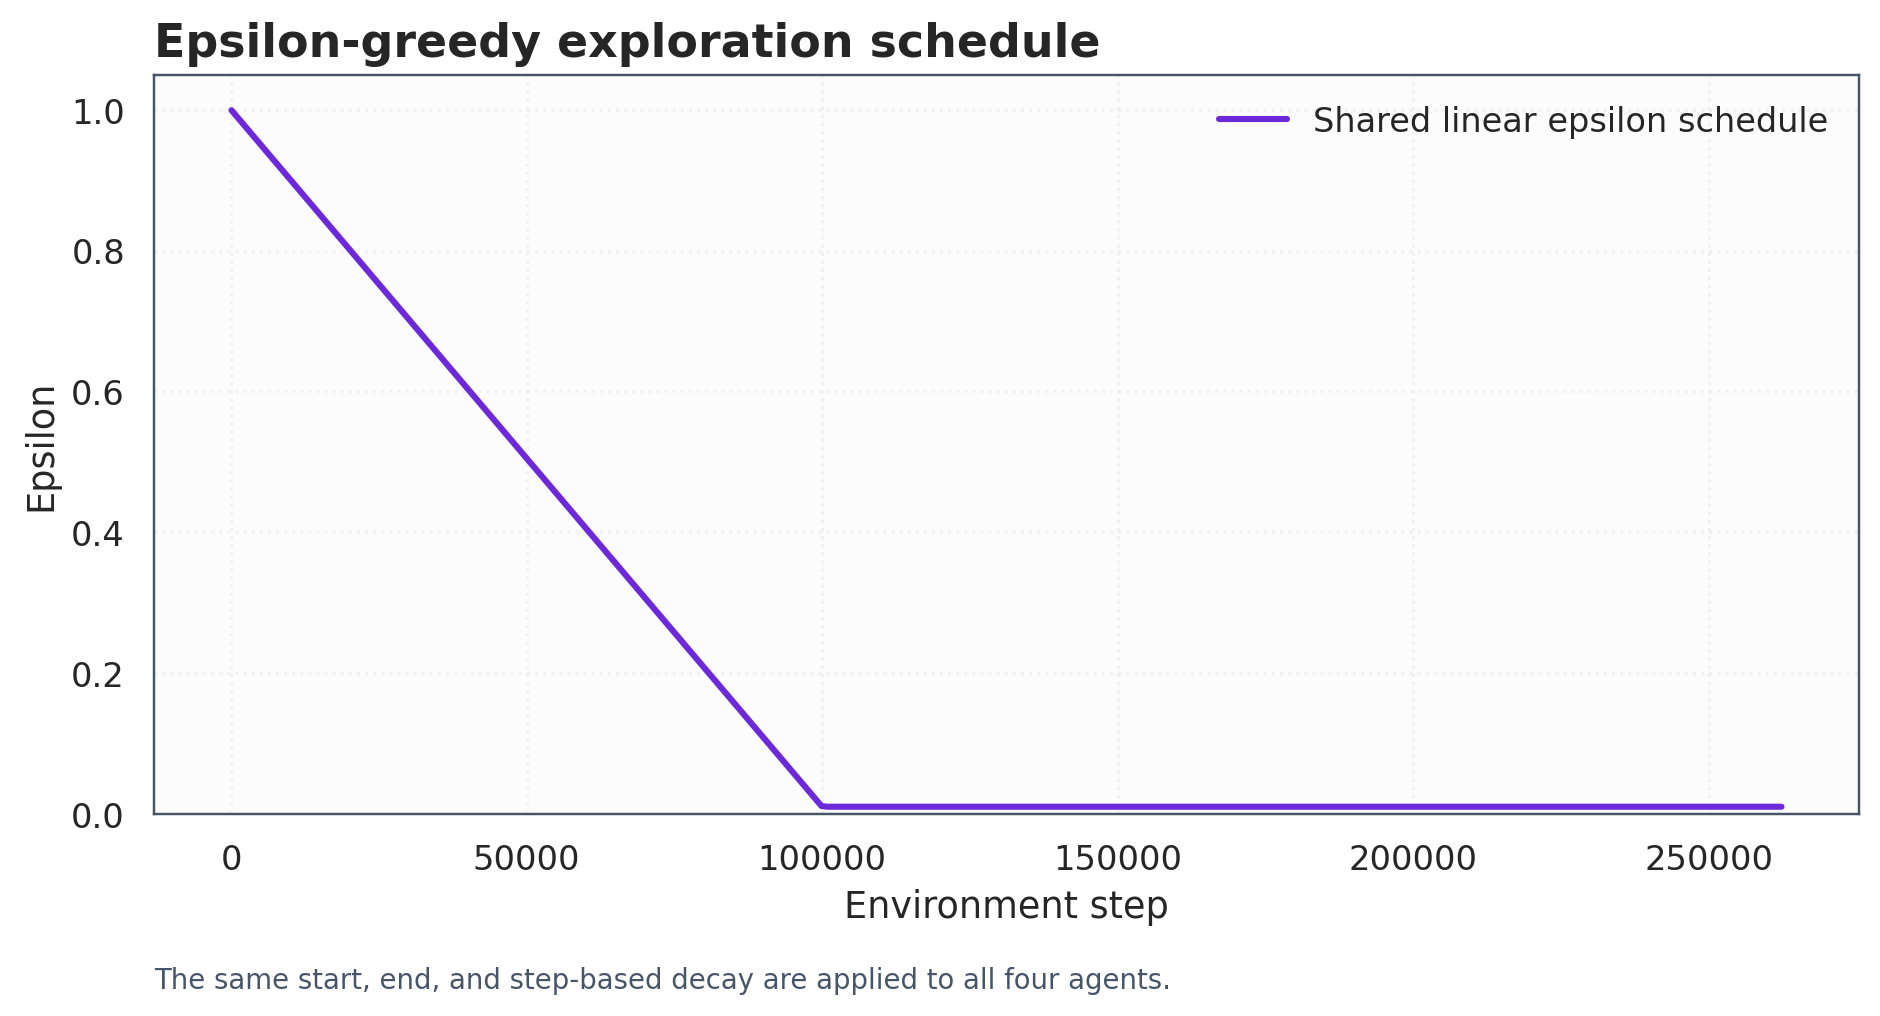

In [12]:
from robust_lunarlander.config import linear_epsilon
epsilon_steps = [0, CONFIG.epsilon_decay_steps // 2, CONFIG.epsilon_decay_steps, CONFIG.epsilon_decay_steps * 2]
epsilon_table = pd.DataFrame({
    'Environment step': epsilon_steps,
    'Epsilon': [linear_epsilon(step, CONFIG) for step in epsilon_steps],
})
display(epsilon_table)
display(Image(filename=str(ARTIFACTS / 'plots' / 'epsilon_schedule.png'), width=900))


## 11. Fixed validation-state set

**Purpose.** Prove that one immutable state set is reused for every Q-value comparison.

**Expected output after execution.** Shape `(512, 8)` and a SHA-256 digest matching provenance.

**Virtual-lab evidence.** Capture shape and digest once.

**Assignment mapping.** Fair fixed-set Q-value comparison.

In [13]:
validation_path = ARTIFACTS / 'validation' / 'fixed_validation_states.npz'
validation_states = np.load(validation_path)['states']
validation_hash = hashlib.sha256(validation_states.tobytes()).hexdigest()
provenance = json.loads((ARTIFACTS / 'system_provenance.json').read_text())
print('Validation shape:', validation_states.shape)
print('Validation SHA-256:', validation_hash)
assert validation_hash == provenance['validation_set_sha256']
validation_states.setflags(write=False)
print('Array writeable:', validation_states.flags.writeable)


Validation shape: (512, 8)
Validation SHA-256: b765a8c76d9ffa0e93207cc98d3bda2bf16adca80d38c8871380e832e25c7f8a
Array writeable: False


## 12. Controlled four-run experiment

**Purpose.** Train fresh DQN/DDQN agents on original/modified environments with identical settings and persist every episode.

**Expected output after execution.** One compact line per episode, four 800-row CSVs/logs, checkpoints, plots, configuration, validation states, and summaries.

**Virtual-lab evidence.** Capture timestamped progress during each run and final saved files. Do not present interrupted runs as complete.

**Assignment mapping.** DQN 4 marks, DDQN 4 marks, and performance evaluation 2 marks.

Set `RUN_FULL_TRAINING=1` before launching Jupyter only when a fresh full run is intended. The recommended lab workflow runs `make study` first, then rebuilds and executes this notebook.

In [14]:
RUN_FULL_TRAINING = os.environ.get('RUN_FULL_TRAINING', '0') == '1'
if RUN_FULL_TRAINING:
    from robust_lunarlander.experiment import run_complete_study
    run_complete_study(CONFIG, force=True)
else:
    print('Reusing recorded complete artifacts. Set RUN_FULL_TRAINING=1 '
          'before launch for a fresh run.')
for name in ('dqn_original', 'ddqn_original', 'dqn_modified', 'ddqn_modified'):
    frame = pd.read_csv(ARTIFACTS / 'metrics' / f'{name}.csv')
    log_lines = (ARTIFACTS / 'logs' / f'{name}.log').read_text().splitlines()
    print(f'{name}: CSV rows={len(frame)}, progress records={len(log_lines)-1}, '
          f'episodes={frame.episode.min()}-{frame.episode.max()}')
    assert len(frame) == CONFIG.episodes
    assert len(log_lines) - 1 == CONFIG.episodes


Reusing recorded complete artifacts. Set RUN_FULL_TRAINING=1 before launch for a fresh run.
dqn_original: CSV rows=800, progress records=800, episodes=1-800
ddqn_original: CSV rows=800, progress records=800, episodes=1-800
dqn_modified: CSV rows=800, progress records=800, episodes=1-800
ddqn_modified: CSV rows=800, progress records=800, episodes=1-800


## 13. Per-episode metrics and compact iteration evidence

**Purpose.** Show the required schema and representative notebook output; the PDF appendix holds the complete 3,200-row record.

**Expected output after execution.** Schema audit plus first/last rows for each experiment.

**Virtual-lab evidence.** Capture representative beginning/end rows and row-count evidence.

**Assignment mapping.** Code quality and reproducible execution evidence.

All iterations remain in `artifacts/metrics/*.csv` and `artifacts/logs/*.log`. Appendix B of the submission PDF includes all 3,200 compact per-iteration records; this notebook displays only beginning/end rows for readability.

In [15]:
required_metric_columns = {
    'episode', 'episode_reward', 'average_predicted_q',
    'successful_safe_landing', 'moving_safe_landing_rate_100',
    'attempted_thruster_activations', 'executed_thruster_activations',
    'average_attempted_thruster_activations_per_episode',
    'episode_steps', 'epsilon', 'training_loss', 'environment_type',
    'algorithm', 'random_seed', 'episode_seconds',
}
for name in ('dqn_original', 'ddqn_original', 'dqn_modified', 'ddqn_modified'):
    frame = pd.read_csv(ARTIFACTS / 'metrics' / f'{name}.csv')
    assert required_metric_columns.issubset(frame.columns)
    excerpt = pd.concat([frame.head(5), frame.tail(5)])
    display(Markdown(f'### {name.replace("_", " ").title()}'))
    display(excerpt[[
        'episode', 'episode_reward', 'average_predicted_q',
        'moving_safe_landing_rate_100',
        'attempted_thruster_activations',
        'executed_thruster_activations', 'epsilon'
    ]])


### Dqn Original

,episode,episode_reward,average_predicted_q,moving_safe_landing_rate_100,attempted_thruster_activations,executed_thruster_activations,epsilon
0,1,-132.792189,0.239278,0.00,51,51,0.999297
1,2,-436.569094,0.239278,0.00,66,66,0.998376
2,3,-112.579064,0.239278,0.00,104,104,0.997149
3,4,-74.448689,0.239278,0.00,67,67,0.996297
4,5,-141.560123,0.239278,0.00,104,104,0.994921
795,796,-22.983878,49.354290,0.36,62,62,0.010000
796,797,-17.395538,50.334686,0.36,66,66,0.010000
797,798,21.899502,50.415394,0.36,89,89,0.010000
798,799,148.520986,47.933060,0.36,797,797,0.010000
799,800,41.603816,49.115871,0.36,84,84,0.010000


### Ddqn Original

,episode,episode_reward,average_predicted_q,moving_safe_landing_rate_100,attempted_thruster_activations,executed_thruster_activations,epsilon
0,1,-132.792189,0.239278,0.00,51,51,0.999297
1,2,-436.569094,0.239278,0.00,66,66,0.998376
2,3,-112.579064,0.239278,0.00,104,104,0.997149
3,4,-74.448689,0.239278,0.00,67,67,0.996297
4,5,-141.560123,0.239278,0.00,104,104,0.994921
795,796,48.493581,81.598343,0.73,108,108,0.010000
796,797,254.513508,80.639282,0.73,227,227,0.010000
797,798,-56.465945,80.275703,0.72,673,673,0.010000
798,799,51.851662,81.211258,0.71,142,142,0.010000
799,800,23.810784,80.514206,0.71,92,92,0.010000


### Dqn Modified

,episode,episode_reward,average_predicted_q,moving_safe_landing_rate_100,attempted_thruster_activations,executed_thruster_activations,epsilon
0,1,-147.061416,0.239278,0.00,50,40,0.999307
1,2,-359.378126,0.239278,0.00,67,61,0.998386
2,3,-158.891221,0.239278,0.00,102,86,0.997178
3,4,-141.977500,0.239278,0.00,67,58,0.996337
4,5,-173.747821,0.239278,0.00,84,72,0.995179
795,796,283.122575,43.461235,0.18,154,134,0.010000
796,797,230.594634,44.314659,0.18,239,206,0.010000
797,798,-96.518348,44.217514,0.18,292,264,0.010000
798,799,-114.746760,48.127720,0.18,762,666,0.010000
799,800,218.855559,48.564922,0.19,269,227,0.010000


### Ddqn Modified

,episode,episode_reward,average_predicted_q,moving_safe_landing_rate_100,attempted_thruster_activations,executed_thruster_activations,epsilon
0,1,-147.061416,0.239278,0.00,50,40,0.999307
1,2,-359.378126,0.239278,0.00,67,61,0.998386
2,3,-158.891221,0.239278,0.00,102,86,0.997178
3,4,-141.977500,0.239278,0.00,67,58,0.996337
4,5,-173.747821,0.239278,0.00,84,72,0.995179
795,796,-303.095685,-7.583429,0.25,801,686,0.010000
796,797,-343.992366,-6.711987,0.24,785,669,0.010000
797,798,-277.566864,-7.290395,0.24,781,676,0.010000
798,799,194.980836,-6.055990,0.24,321,281,0.010000
799,800,268.294557,-6.724810,0.25,178,150,0.010000


## 14. Required comparison plots

**Purpose.** Compare all four agents on the four assignment metrics.

**Expected output after execution.** Reward, fixed-state Q, moving safe-landing rate, and average attempted-thruster plots with titles, axes, legend, grid, and caption.

**Virtual-lab evidence.** Capture the timestamped final-output and plot screen.

**Assignment mapping.** Performance evaluation - 2 marks.

Raw traces are light where useful; moderate smoothing is overlaid without hiding instability.

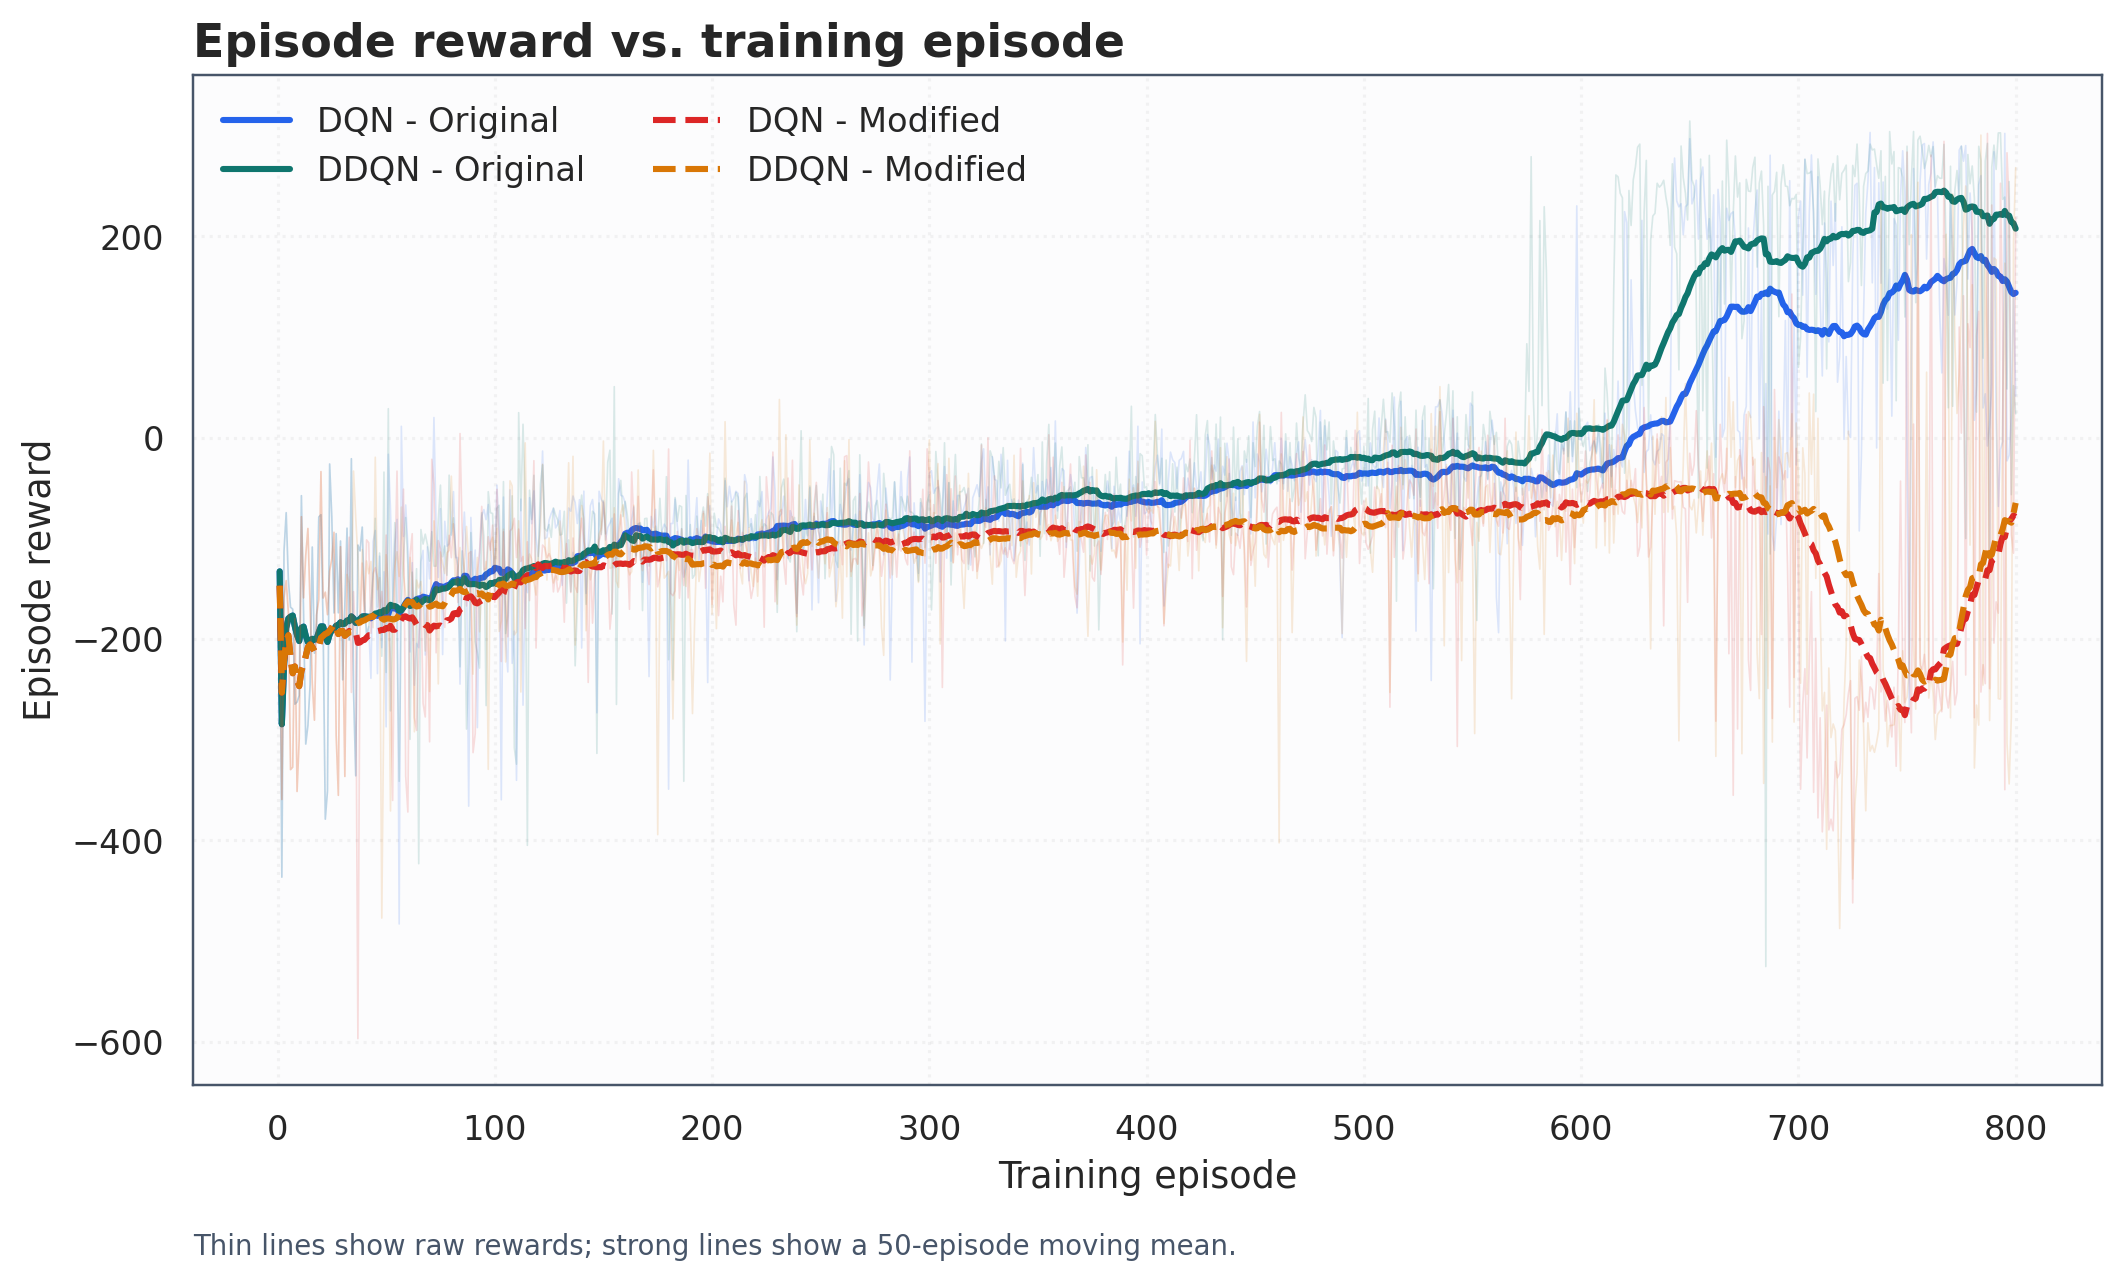

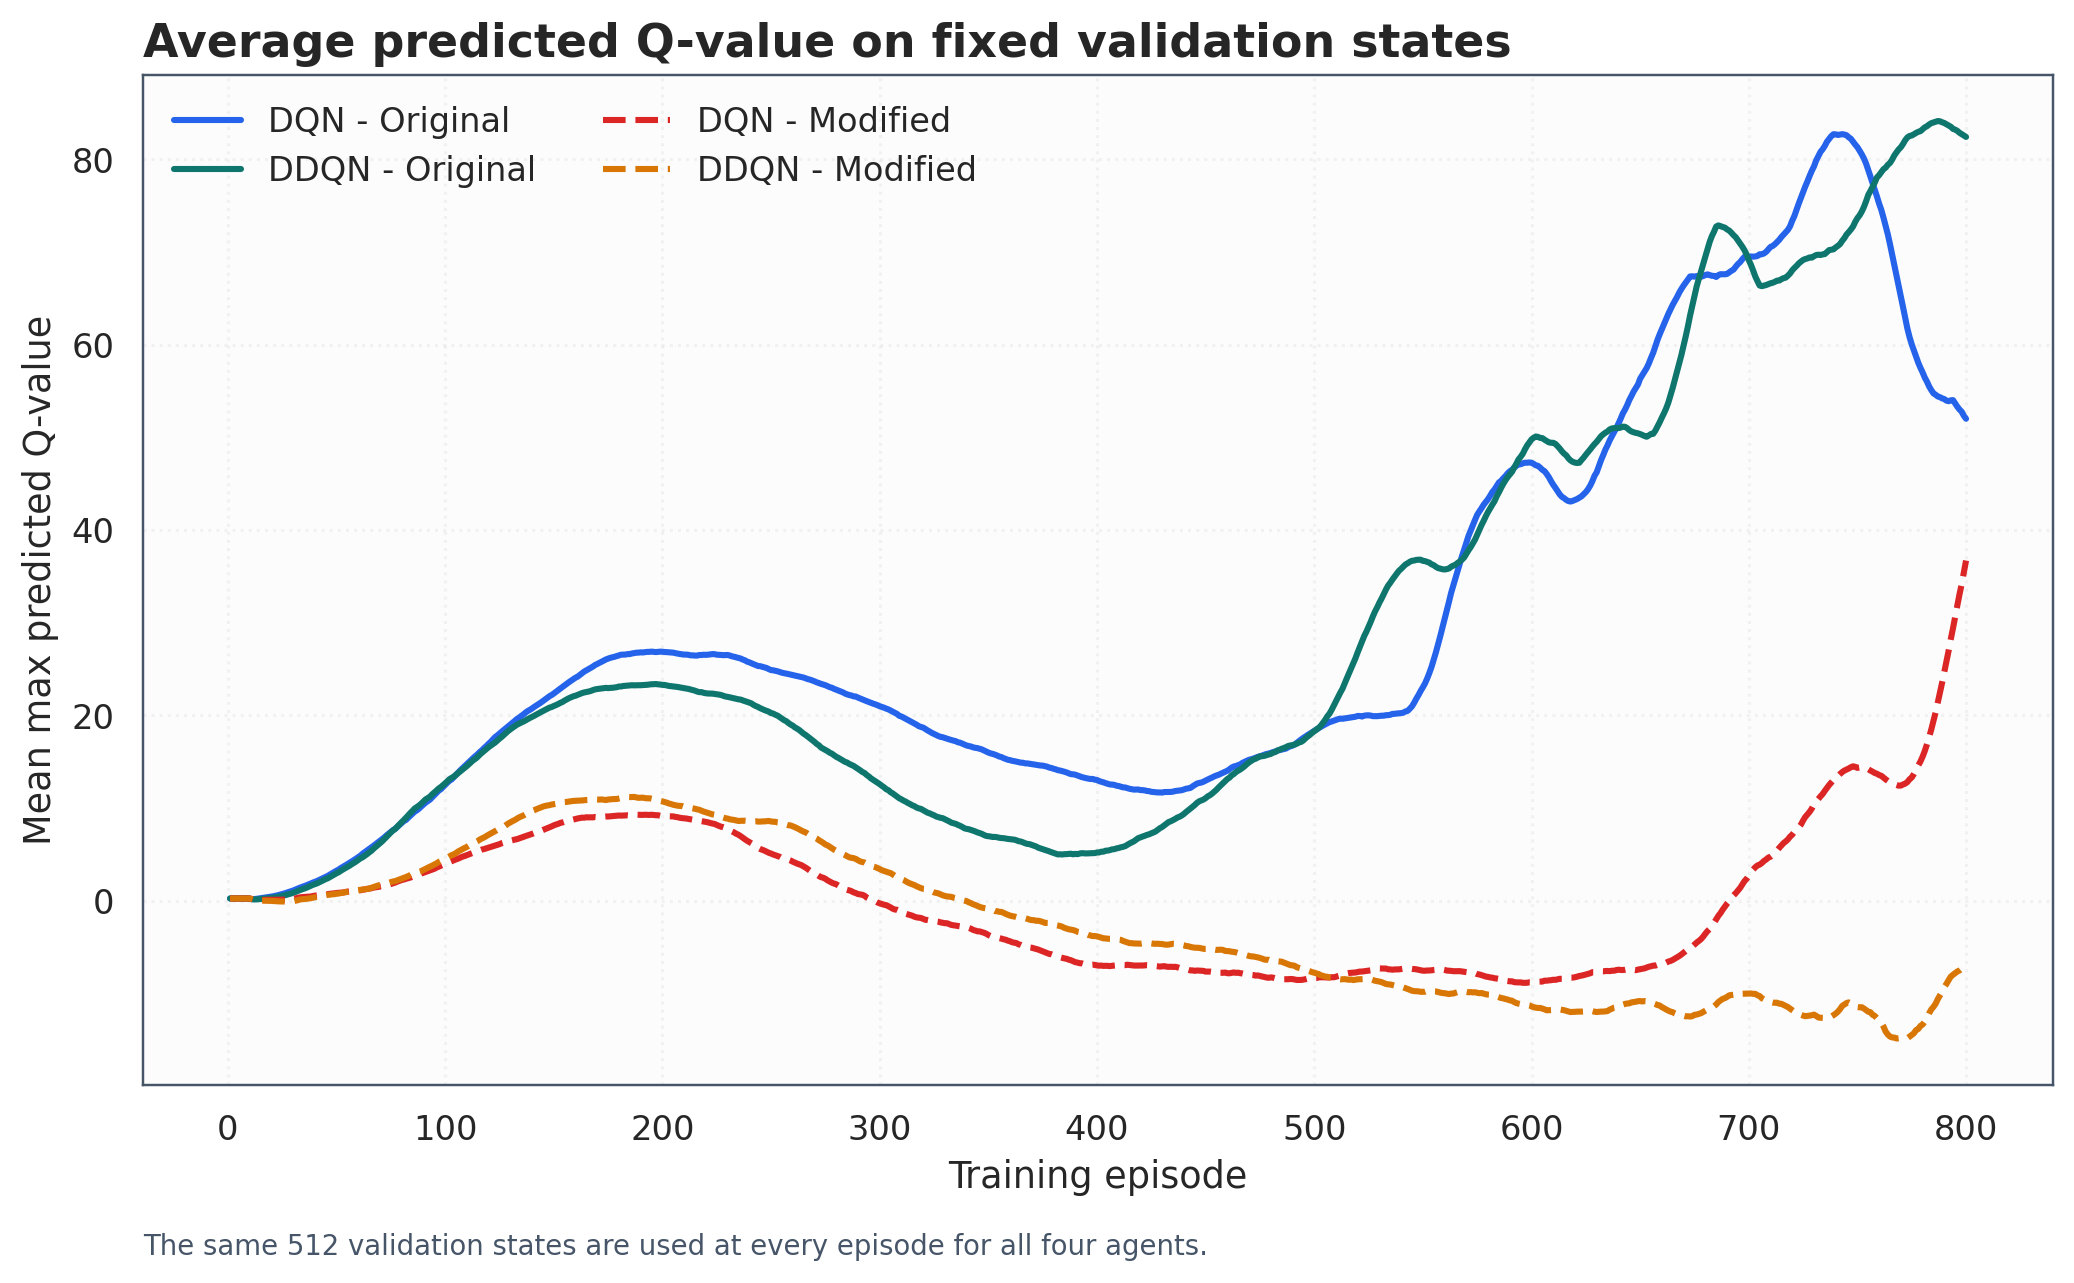

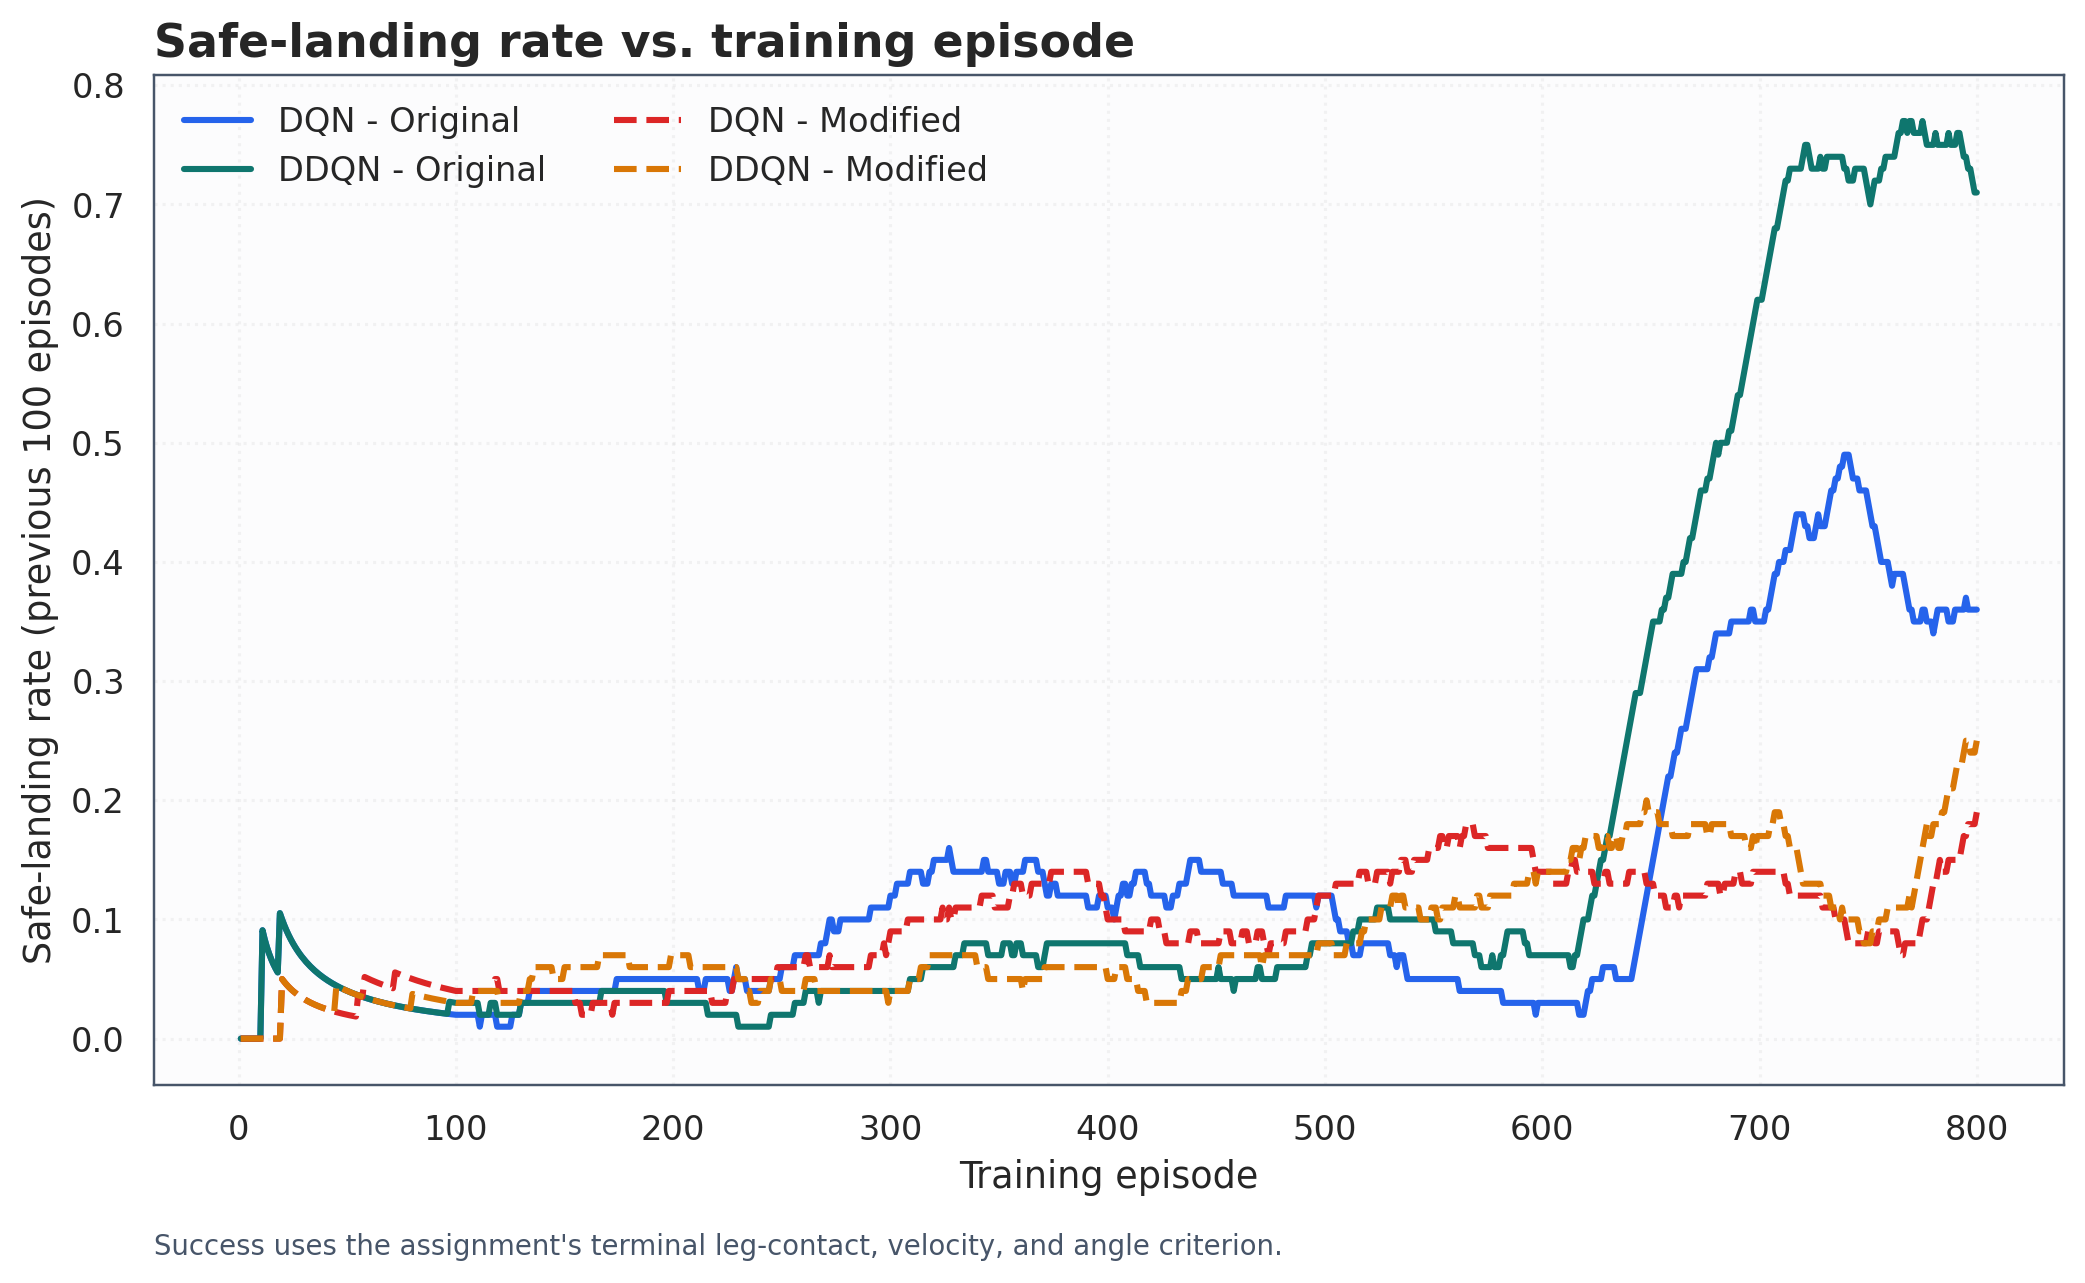

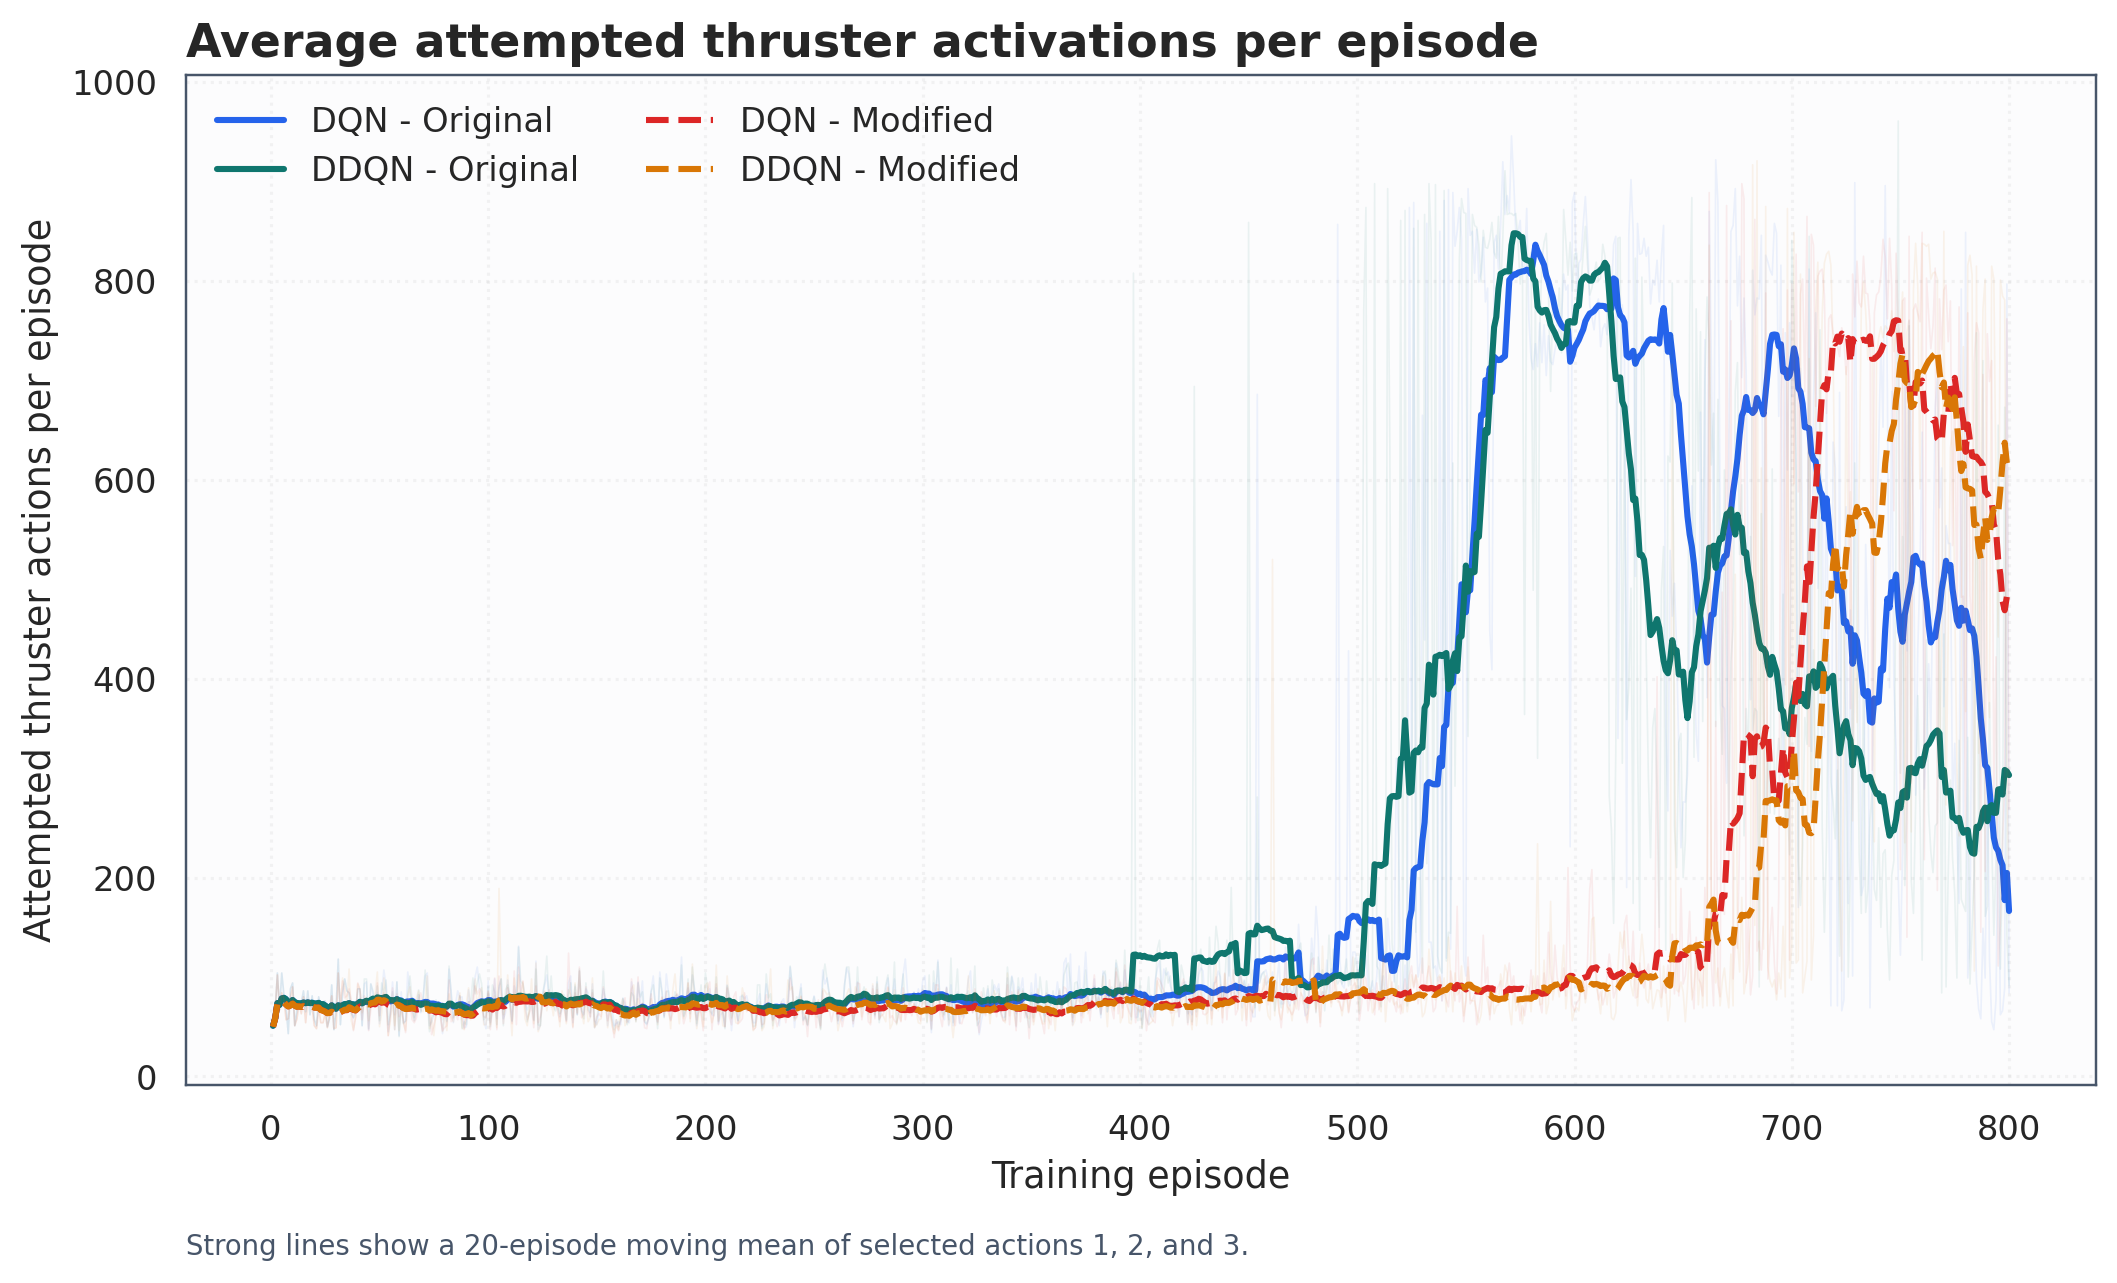

In [16]:
plot_names = [
    'episode_reward.png', 'average_predicted_q.png',
    'success_rate_100.png', 'thruster_activations.png',
]
for plot_name in plot_names:
    display(Image(filename=str(ARTIFACTS / 'plots' / plot_name), width=950))


## 15. Evaluation table

**Purpose.** Report final-100 training statistics and supplementary greedy evaluation.

**Expected output after execution.** Mean/SD reward, best MA(100), final fixed-set Q, final safe rate, attempted/executed actions, successes, and duration for every run.

**Virtual-lab evidence.** Capture the full comparison table.

**Assignment mapping.** Performance evaluation - 2 marks.

In [17]:
final_comparison = pd.read_csv(ARTIFACTS / 'final_comparison.csv')
evaluation = pd.read_csv(ARTIFACTS / 'evaluation_summary.csv')
display(Markdown('### Final-100 training comparison'))
display(final_comparison)
display(Markdown('### Greedy evaluation on 100 shared seeds'))
display(evaluation)


### Final-100 training comparison

,experiment,algorithm,environment,mean_reward_final_100,reward_std_final_100,best_moving_average_reward_100,final_fixed_set_average_q,safe_landing_rate_final_100,mean_attempted_thrusters_final_100,mean_executed_thrusters_final_100,successful_safe_landings_total,training_duration_seconds
0,dqn_original,DQN,Original,150.517531,113.674880,154.397398,49.115871,0.36,409.80,409.80,116,166.630415
1,ddqn_original,DDQN,Original,218.236781,98.014501,226.336542,80.514206,0.71,304.11,304.11,166,137.971260
2,dqn_modified,DQN,Modified,-172.733365,192.672078,-56.870613,48.564922,0.19,655.06,557.94,86,89.090518
3,ddqn_modified,DDQN,Modified,-150.419105,200.688896,-54.053481,-6.724810,0.25,595.74,507.37,83,98.716689


### Greedy evaluation on 100 shared seeds

,experiment,algorithm,environment_type,mean_reward,reward_std,safe_landing_rate,mean_attempted_thruster_activations,mean_executed_thruster_activations,mean_episode_steps
0,ddqn_modified,DDQN,Modified,-225.818927,102.173601,0.03,730.92,622.07,972.34
1,ddqn_original,DDQN,Original,169.045390,136.748626,0.61,250.72,250.72,360.51
2,dqn_modified,DQN,Modified,48.022787,186.727537,0.44,423.85,359.97,615.37
3,dqn_original,DQN,Original,67.153681,95.709754,0.24,138.07,138.07,188.34


## 16. Evidence-based discussion

**Purpose.** Answer all five assignment questions using the recorded study.

**Expected output after execution.** Claims tied to plot panels and numerical table values.

**Virtual-lab evidence.** Capture after the final tables/plots exist.

**Assignment mapping.** Discussion - 2.5 marks.

### 1. Does failure increase the DQN-DDQN Q-value difference?

For this run, the final-100 mean absolute gap changes from 16.23 in the original environment to 28.68 in the modified environment (difference 12.46). This is single-seed evidence, not a population estimate.

### 2. Why is temporal credit assignment harder?

The same selected action can produce a thruster impulse or a no-op without a failure indicator. Replay therefore contains noisier outcomes for similar state-action inputs, while the selected-action cost is certain and the physical effect is uncertain.

### 3. Does the penalty encourage conservation?

No in the attempted-action metric for this run. Greedy DDQN attempts 730.92 actions when modified versus 250.72 when original. Greedy DQN attempts 423.85 versus 138.07. Both modified policies attempt more actions. Longer episodes and compensation for no-op commands may outweigh the 0.3 cost.

### 4. Which algorithm performs better under failure?

The result is metric-dependent. DDQN is slightly better in the final 100 training episodes, but frozen-checkpoint greedy evaluation favors DQN: reward 48.02 and safe rate 44% versus DDQN reward -225.82 and safe rate 3%. This execution does not show an unambiguous DDQN advantage and is not cleanly consistent with the theoretical expectation.

### 5. Limitation and improvement

The study uses one training seed. A paired multi-seed replication with confidence intervals is the most direct improvement.

In [18]:
discussion_evidence = {
    'q_gap_original': 16.22627914428711,
    'q_gap_modified': 28.681840476989745,
    'ddqn_modified_mean_reward': -225.8189272617814,
    'dqn_modified_mean_reward': 48.02278714555646,
}
display(pd.Series(discussion_evidence, name='Recorded value'))


q_gap_original                16.226279
q_gap_modified                28.681840
ddqn_modified_mean_reward   -225.818927
dqn_modified_mean_reward      48.022787
Name: Recorded value, dtype: float64

## 17. Virtual-lab screenshot placeholders

**Purpose.** Reserve exact locations for genuine institutional evidence.

**Expected output after execution.** Existing images display; missing images remain explicit placeholders.

**Virtual-lab evidence.** Use visible timestamps and retain institutional lab identity.

**Assignment mapping.** Virtual-lab evidence and submission readiness.

- `01_start_timestamp.png`: beginning of execution
- `02_environment_versions.png`: package/environment evidence
- `03_training_progress.png`: timestamped training
- `04_final_outputs_plots.png`: final tables and plots
- `05_saved_artifacts.png`: CSV/checkpoints/validation/plots

Do not fabricate or substitute local screenshots.

In [19]:
screenshot_dir = REPO / 'submission' / 'virtual_lab'
screenshot_specs = {
    '01_start_timestamp.png': 'Beginning timestamp',
    '02_environment_versions.png': 'Environment versions',
    '03_training_progress.png': 'Training progress',
    '04_final_outputs_plots.png': 'Final outputs and plots',
    '05_saved_artifacts.png': 'Saved artifacts',
}
for filename, label in screenshot_specs.items():
    path = screenshot_dir / filename
    if path.exists():
        display(Markdown(f'### {label}'))
        display(Image(filename=str(path), width=1000))
    else:
        print(f'[INSERT VIRTUAL-LAB SCREENSHOT WITH VISIBLE TIMESTAMP HERE] '
              f'{label}: {path.relative_to(REPO)}')


[INSERT VIRTUAL-LAB SCREENSHOT WITH VISIBLE TIMESTAMP HERE] Beginning timestamp: submission/virtual_lab/01_start_timestamp.png
[INSERT VIRTUAL-LAB SCREENSHOT WITH VISIBLE TIMESTAMP HERE] Environment versions: submission/virtual_lab/02_environment_versions.png
[INSERT VIRTUAL-LAB SCREENSHOT WITH VISIBLE TIMESTAMP HERE] Training progress: submission/virtual_lab/03_training_progress.png
[INSERT VIRTUAL-LAB SCREENSHOT WITH VISIBLE TIMESTAMP HERE] Final outputs and plots: submission/virtual_lab/04_final_outputs_plots.png
[INSERT VIRTUAL-LAB SCREENSHOT WITH VISIBLE TIMESTAMP HERE] Saved artifacts: submission/virtual_lab/05_saved_artifacts.png


## 18. Conclusion

**Purpose.** Summarize only the strongest recorded evidence and limitation.

**Expected output after execution.** A concise result-dependent conclusion.

**Virtual-lab evidence.** Capture only after the official run and final plots complete.

**Assignment mapping.** Conclusion and Discussion - 2.5 marks.

In the recorded run, hidden actuator failure changes the final-100 DQN-DDQN fixed-state Q-gap from 16.23 to 28.68. The attempted fuel penalty did not reduce attempted activations in the modified runs. DDQN is slightly stronger in the final training window, while DQN is substantially stronger in greedy evaluation, so no algorithm wins every metric. The main limitation is the single seed. Rebuild this notebook if the official virtual-lab outputs change.

In [20]:
audit_run = subprocess.run(
    [sys.executable, 'scripts/audit_artifacts.py'],
    cwd=REPO,
    capture_output=True,
    text=True,
    check=True,
)
print(audit_run.stdout)


PASS  training duration: 800 episodes per agent
PASS  shared seed: seed=148
PASS  fixed validation set shape: shape=(512, 8)
PASS  fixed validation set hash: b765a8c76d9ffa0e93207cc98d3bda2bf16adca80d38c8871380e832e25c7f8a
PASS  dqn_original episode ledger: rows=800, range=1-800, schema=True
PASS  dqn_original per-episode progress log: records=800
PASS  dqn_original checkpoint: 301373 bytes
PASS  ddqn_original episode ledger: rows=800, range=1-800, schema=True
PASS  ddqn_original per-episode progress log: records=800
PASS  ddqn_original checkpoint: 301409 bytes
PASS  dqn_modified episode ledger: rows=800, range=1-800, schema=True
PASS  dqn_modified per-episode progress log: records=800
PASS  dqn_modified checkpoint: 301373 bytes
PASS  ddqn_modified episode ledger: rows=800, range=1-800, schema=True
PASS  ddqn_modified per-episode progress log: records=800
PASS  ddqn_modified checkpoint: 301409 bytes
PASS  greedy evaluation coverage: {'ddqn_modified': 100, 'ddqn_original': 100, 'dqn_mod

## 19. Complete commented source appendix

**Purpose.** Expose the exact modular implementation used by the study.

**Expected output after execution.** All eight source modules printed from disk without replay tensors.

**Virtual-lab evidence.** The PDF report contains the same syntax-highlighted listings.

**Assignment mapping.** Code quality across all rubric sections.

In [21]:
source_files = ('src/robust_lunarlander/config.py', 'src/robust_lunarlander/envs.py', 'src/robust_lunarlander/network.py', 'src/robust_lunarlander/replay.py', 'src/robust_lunarlander/agent.py', 'src/robust_lunarlander/verification.py', 'src/robust_lunarlander/experiment.py', 'src/robust_lunarlander/plotting.py')
for relative_path in source_files:
    display(Markdown(f'### {relative_path}'))
    source = (REPO / relative_path).read_text(encoding='utf-8')
    display(Markdown(f'```python\n{source}\n```'))


### src/robust_lunarlander/config.py

```python
"""Central configuration for fair and reproducible DQN/DDQN experiments."""

from __future__ import annotations

from dataclasses import asdict, dataclass
from pathlib import Path
from typing import Any


@dataclass(frozen=True)
class TrainingConfig:
    """Store every experimental choice shared by all four training runs."""

    seed: int = 148
    episodes: int = 800
    max_steps_per_episode: int = 1_000
    gamma: float = 0.99
    learning_rate: float = 5e-4
    batch_size: int = 64
    replay_capacity: int = 100_000
    learning_starts: int = 1_000
    train_frequency: int = 1
    target_update_interval: int = 500
    epsilon_start: float = 1.0
    epsilon_end: float = 0.01
    epsilon_decay_steps: int = 100_000
    hidden_sizes: tuple[int, int] = (128, 128)
    gradient_clip_norm: float = 10.0
    validation_state_count: int = 512
    evaluation_episodes: int = 100
    failure_probability: float = 0.15
    attempted_thruster_penalty: float = 0.3
    safe_landing_bonus: float = 50.0
    device: str = "cpu"
    output_dir: Path = Path("artifacts")

    def as_serializable_dict(self) -> dict[str, Any]:
        """Return a JSON-safe representation suitable for provenance files."""

        values = asdict(self)
        values["output_dir"] = str(self.output_dir)
        values["hidden_sizes"] = list(self.hidden_sizes)
        return values


def linear_epsilon(step: int, config: TrainingConfig) -> float:
    """Linearly anneal epsilon from its start value to its final value."""

    progress = min(max(step, 0) / config.epsilon_decay_steps, 1.0)
    return config.epsilon_start + progress * (config.epsilon_end - config.epsilon_start)

```

### src/robust_lunarlander/envs.py

```python
"""Environment construction and the assignment-specified action-failure wrapper."""

from __future__ import annotations

from copy import deepcopy
from typing import Any

import gymnasium as gym
import numpy as np


def is_safe_landing(
    observation: np.ndarray,
    terminated: bool,
    truncated: bool,
) -> bool:
    """Return True only when every assignment safe-landing condition is met."""

    observation = np.asarray(observation)
    return bool(
        terminated
        and not truncated
        and observation[6] == 1
        and observation[7] == 1
        and abs(float(observation[2])) < 0.10
        and abs(float(observation[3])) < 0.10
        and abs(float(observation[4])) < 0.10
    )


class StochasticActionFailureWrapper(gym.Wrapper):
    """Apply hidden thruster failures, attempted-fuel cost, and safe-landing bonus.

    The selected and executed actions are retained only in private verification
    counters. The returned observation, termination flags, truncation flag, and
    info object come directly from the base environment. In particular, no failure
    indicator is leaked to the agent.

    A private RNG is used for actuator failures so drawing the failure event does
    not consume random numbers from LunarLander's own transition generator.
    """

    def __init__(
        self,
        env: gym.Env,
        failure_probability: float = 0.15,
        attempted_thruster_penalty: float = 0.3,
        safe_landing_bonus: float = 50.0,
    ) -> None:
        """Initialize the wrapper while preserving the base action and observation spaces."""

        super().__init__(env)
        if not 0.0 <= failure_probability <= 1.0:
            raise ValueError("failure_probability must lie in [0, 1].")
        if attempted_thruster_penalty < 0.0:
            raise ValueError("attempted_thruster_penalty must be non-negative.")
        self.failure_probability = float(failure_probability)
        self.attempted_thruster_penalty = float(attempted_thruster_penalty)
        self.safe_landing_bonus = float(safe_landing_bonus)
        self._failure_rng = np.random.default_rng()
        self._verification_counters = {
            "attempted_thruster_actions": 0,
            "misfired_thruster_actions": 0,
            "executed_thruster_actions": 0,
            "applied_fuel_penalties": 0,
            "safe_landing_bonuses": 0,
        }

    @property
    def verification_counters(self) -> dict[str, int]:
        """Return a defensive copy of private counters for external verification."""

        return deepcopy(self._verification_counters)

    def clear_verification_counters(self) -> None:
        """Reset private counters without changing any agent-visible state."""

        for key in self._verification_counters:
            self._verification_counters[key] = 0

    def reset(
        self,
        *,
        seed: int | None = None,
        options: dict[str, Any] | None = None,
    ) -> tuple[np.ndarray, dict[str, Any]]:
        """Reset LunarLander and independently seed the hidden failure process."""

        if seed is not None:
            # A distinct SeedSequence component avoids coupling failure draws to
            # the base environment even though both originate from one run seed.
            failure_seed = np.random.SeedSequence([int(seed), 0xFA11])
            self._failure_rng = np.random.default_rng(failure_seed)
        return self.env.reset(seed=seed, options=options)

    def step(
        self,
        action: int,
    ) -> tuple[np.ndarray, float, bool, bool, dict[str, Any]]:
        """Execute one assignment-compliant transition in the specified order."""

        selected_action = int(action)
        if not self.action_space.contains(selected_action):
            raise ValueError(f"Invalid action {selected_action!r} for {self.action_space}.")

        # Only a selected thruster command can fail. Action zero is never replaced.
        executed_action = selected_action
        if selected_action in (1, 2, 3):
            self._verification_counters["attempted_thruster_actions"] += 1
            if self._failure_rng.random() < self.failure_probability:
                executed_action = 0
                self._verification_counters["misfired_thruster_actions"] += 1
            else:
                self._verification_counters["executed_thruster_actions"] += 1

        # Delegate the final action to the unchanged LunarLander transition logic.
        observation, base_reward, terminated, truncated, info = self.env.step(executed_action)

        fuel_cost = self.attempted_thruster_penalty if selected_action != 0 else 0.0
        self._verification_counters["applied_fuel_penalties"] += int(selected_action != 0)
        landing_bonus = (
            self.safe_landing_bonus if is_safe_landing(observation, terminated, truncated) else 0.0
        )
        self._verification_counters["safe_landing_bonuses"] += int(landing_bonus != 0.0)
        modified_reward = float(base_reward) - fuel_cost + landing_bonus

        # Return the base info object exactly; diagnostics remain private.
        return observation, modified_reward, terminated, truncated, info


def make_environment(
    *,
    modified: bool,
    failure_probability: float = 0.15,
    attempted_thruster_penalty: float = 0.3,
    safe_landing_bonus: float = 50.0,
    render_mode: str | None = None,
) -> gym.Env:
    """Create either original LunarLander-v3 or the specified modified variant."""

    base_environment = gym.make("LunarLander-v3", render_mode=render_mode)
    if not modified:
        return base_environment
    return StochasticActionFailureWrapper(
        base_environment,
        failure_probability=failure_probability,
        attempted_thruster_penalty=attempted_thruster_penalty,
        safe_landing_bonus=safe_landing_bonus,
    )

```

### src/robust_lunarlander/network.py

...

```python
"""Experimental and boundary verification of the modified environment."""

from __future__ import annotations

import argparse
import json
import math
import platform
import sys
from dataclasses import dataclass
from datetime import datetime
from pathlib import Path
from typing import Any

import gymnasium as gym
import numpy as np
import pandas as pd
from gymnasium import spaces

from .envs import StochasticActionFailureWrapper, is_safe_landing


class ActionRewardSpy(gym.Wrapper):
    """Record base-environment inputs and outputs outside the agent-facing wrapper."""

    def __init__(self, env: gym.Env) -> None:
        """Initialize an empty last-transition record."""

        super().__init__(env)
        self.last: dict[str, Any] | None = None

    def step(
        self,
        action: int,
    ) -> tuple[np.ndarray, float, bool, bool, dict[str, Any]]:
        """Forward the action and retain the unmodified response for verification."""

        observation, reward, terminated, truncated, info = self.env.step(action)
        self.last = {
            "executed_action": int(action),
            "observation": np.asarray(observation).copy(),
            "base_reward": float(reward),
            "terminated": bool(terminated),
            "truncated": bool(truncated),
            "info": info,
        }
        return observation, reward, terminated, truncated, info


class ScriptedTerminalEnvironment(gym.Env):
    """Return one specified terminal transition for controlled reward tests."""

    metadata: dict[str, Any] = {}

    def __init__(
        self,
        observation: np.ndarray,
        *,
        base_reward: float = 7.0,
        terminated: bool = True,
        truncated: bool = False,
    ) -> None:
        """Store the exact response that step must return."""

        super().__init__()
        self.action_space = spaces.Discrete(4)
        self.observation_space = spaces.Box(-np.inf, np.inf, shape=(8,), dtype=np.float32)
        self.response_observation = np.asarray(observation, dtype=np.float32)
        self.base_reward = float(base_reward)
        self.terminated = bool(terminated)
        self.truncated = bool(truncated)
        self.received_action: int | None = None
        self.info_object = {"source": "scripted-base"}

    def reset(
        self,
        *,
        seed: int | None = None,
        options: dict[str, Any] | None = None,
    ) -> tuple[np.ndarray, dict[str, Any]]:
        """Reset Gymnasium's random generator and return a neutral observation."""

        super().reset(seed=seed)
        del options
        return np.zeros(8, dtype=np.float32), {}

    def step(
        self,
        action: int,
    ) -> tuple[np.ndarray, float, bool, bool, dict[str, Any]]:
        """Return the configured response while recording the executed action."""

        self.received_action = int(action)
        return (
            self.response_observation.copy(),
            self.base_reward,
            self.terminated,
            self.truncated,
            self.info_object,
        )


@dataclass(frozen=True)
class BoundaryCase:
    """Describe one controlled safe-landing or fuel-penalty check."""

    name: str
    observation: list[float]
    terminated: bool
    truncated: bool
    selected_action: int
    failure_probability: float
    expected_bonus: float
    expected_executed_action: int


def _safe_observation() -> np.ndarray:
    """Return an observation satisfying all five state thresholds."""

    return np.array([0.0, 0.0, 0.02, -0.03, 0.04, 0.0, 1.0, 1.0], dtype=np.float32)


def controlled_boundary_cases() -> list[BoundaryCase]:
    """Enumerate positive, negative, boundary, truncation, and misfire cases."""

    safe = _safe_observation()
    cases: list[BoundaryCase] = [
        BoundaryCase("all_conditions_true", safe.tolist(), True, False, 0, 0.0, 50.0, 0),
        BoundaryCase("attempted_thruster_success", safe.tolist(), True, False, 2, 0.0, 50.0, 2),
        BoundaryCase("attempted_thruster_misfire", safe.tolist(), True, False, 2, 1.0, 50.0, 0),
    ]
    mutations = [
        ("not_terminated", 2, 0.02, False, False),
        ("episode_truncated", 2, 0.02, True, True),
        ("left_leg_absent", 6, 0.0, True, False),
        ("right_leg_absent", 7, 0.0, True, False),
        ("excess_horizontal_velocity", 2, 0.11, True, False),
        ("excess_vertical_velocity", 3, -0.11, True, False),
        ("excess_orientation_angle", 4, 0.11, True, False),
    ]
    for name, index, value, terminated, truncated in mutations:
        observation = safe.copy()
        observation[index] = value
        cases.append(
            BoundaryCase(
                name,
                observation.tolist(),
                terminated,
                truncated,
                0,
                0.0,
                0.0,
                0,
            )
        )
    return cases


def run_controlled_boundary_verification() -> pd.DataFrame:
    """Execute every controlled case and prove exact reward/action semantics."""

    rows: list[dict[str, Any]] = []
    for case in controlled_boundary_cases():
        base = ScriptedTerminalEnvironment(
            np.asarray(case.observation, dtype=np.float32),
            terminated=case.terminated,
            truncated=case.truncated,
        )
        wrapped = StochasticActionFailureWrapper(
            base,
            failure_probability=case.failure_probability,
        )
        wrapped.reset(seed=148)
        observation, reward, terminated, truncated, returned_info = wrapped.step(
            case.selected_action
        )
        counters = wrapped.verification_counters
        expected_penalty = 0.3 if case.selected_action != 0 else 0.0
        expected_reward = base.base_reward - expected_penalty + case.expected_bonus
        rows.append(
            {
                "case": case.name,
                "selected_action": case.selected_action,
                "executed_action": base.received_action,
                "expected_executed_action": case.expected_executed_action,
                "safe_landing_detected": is_safe_landing(observation, terminated, truncated),
                "expected_bonus": case.expected_bonus,
                "observed_reward": float(reward),
                "expected_reward": expected_reward,
                "fuel_penalty": expected_penalty,
                "counter_attempted_actions": counters["attempted_thruster_actions"],
                "counter_executed_actions": counters["executed_thruster_actions"],
                "counter_misfires": counters["misfired_thruster_actions"],
                "info_identity_preserved": returned_info is base.info_object,
                "passed": bool(
                    base.received_action == case.expected_executed_action
                    and math.isclose(float(reward), expected_reward, abs_tol=1e-7)
                    and returned_info is base.info_object
                    and counters["applied_fuel_penalties"] == int(case.selected_action != 0)
                    and counters["safe_landing_bonuses"] == int(case.expected_bonus != 0.0)
                ),
            }
        )
        wrapped.close()
    return pd.DataFrame(rows)


def _wilson_interval(successes: int, trials: int) -> tuple[float, float]:
    """Return a 95 percent Wilson score interval for a binomial proportion."""

    if trials == 0:
        return float("nan"), float("nan")
    z = 1.959963984540054
    proportion = successes / trials
    denominator = 1.0 + z * z / trials
    centre = (proportion + z * z / (2.0 * trials)) / denominator
    radius = (
        z
        * math.sqrt(proportion * (1.0 - proportion) / trials + z * z / (4.0 * trials * trials))
        / denominator
    )
    return centre - radius, centre + radius


def run_random_policy_verification(
    *,
    episodes: int,
    seed: int,
) -> tuple[dict[str, Any], pd.DataFrame]:
    """Run many random LunarLander episodes and compare selected/executed actions."""

    spy = ActionRewardSpy(gym.make("LunarLander-v3"))
    environment = StochasticActionFailureWrapper(spy)
    action_rng = np.random.default_rng(seed + 10_000)
    records: list[dict[str, Any]] = []
    total_steps = 0
    attempted_thrusters = 0
    misfires = 0
    penalty_checks = 0
    penalty_mismatches = 0
    info_identity_mismatches = 0
    unexpected_action_replacements = 0
    observed_safe_landings = 0

    for episode in range(1, episodes + 1):
        observation, _ = environment.reset(seed=seed + episode - 1)
        del observation
        terminated = truncated = False
        episode_step = 0
        while not (terminated or truncated):
            selected_action = int(action_rng.integers(environment.action_space.n))
            observation, reward, terminated, truncated, info = environment.step(selected_action)
            if spy.last is None:
                raise RuntimeError("The verification spy did not record a base transition.")

            executed_action = int(spy.last["executed_action"])
            safe = is_safe_landing(observation, terminated, truncated)
            expected_penalty = 0.3 if selected_action != 0 else 0.0
            expected_bonus = 50.0 if safe else 0.0
            expected_reward = float(spy.last["base_reward"]) - expected_penalty + expected_bonus
            penalty_ok = math.isclose(float(reward), expected_reward, abs_tol=1e-6)

            if selected_action != 0:
                attempted_thrusters += 1
                penalty_checks += 1
                misfires += int(executed_action == 0)
                penalty_mismatches += int(not penalty_ok)
                unexpected_action_replacements += int(executed_action not in (0, selected_action))
            else:
                unexpected_action_replacements += int(executed_action != 0)
            info_identity_mismatches += int(info is not spy.last["info"])
            observed_safe_landings += int(safe)
            total_steps += 1
            episode_step += 1

            if len(records) < 500:
                records.append(
                    {
                        "episode": episode,
                        "step": episode_step,
                        "selected_action": selected_action,
                        "executed_action": executed_action,
                        "misfire": selected_action != 0 and executed_action == 0,
                        "base_reward": float(spy.last["base_reward"]),
                        "modified_reward": float(reward),
                        "expected_fuel_penalty": expected_penalty,
                        "safe_landing_bonus": expected_bonus,
                        "reward_check_passed": penalty_ok,
                    }
                )

    internal_counters = environment.verification_counters
    environment.close()
    interval_low, interval_high = _wilson_interval(misfires, attempted_thrusters)
    observed_rate = misfires / attempted_thrusters
    summary = {
        "episodes": episodes,
        "total_steps": total_steps,
        "attempted_thruster_actions": attempted_thrusters,
        "misfired_thruster_actions": misfires,
        "observed_misfire_rate": observed_rate,
        "target_misfire_rate": 0.15,
        "misfire_rate_absolute_error": abs(observed_rate - 0.15),
        "misfire_rate_wilson_95_low": interval_low,
        "misfire_rate_wilson_95_high": interval_high,
        "target_inside_wilson_interval": interval_low <= 0.15 <= interval_high,
        "fuel_penalty_checks": penalty_checks,
        "fuel_penalty_count": internal_counters["applied_fuel_penalties"],
        "fuel_penalty_count_matches_attempts": (
            internal_counters["applied_fuel_penalties"] == attempted_thrusters
        ),
        "fuel_penalty_mismatches": penalty_mismatches,
        "internal_attempt_count_matches": (
            internal_counters["attempted_thruster_actions"] == attempted_thrusters
        ),
        "internal_misfire_count_matches": (
            internal_counters["misfired_thruster_actions"] == misfires
        ),
        "executed_thruster_actions": internal_counters["executed_thruster_actions"],
        "safe_landing_bonus_count": internal_counters["safe_landing_bonuses"],
        "safe_landing_bonus_count_matches": (
            internal_counters["safe_landing_bonuses"] == observed_safe_landings
        ),
        "info_identity_mismatches": info_identity_mismatches,
        "unexpected_action_replacements": unexpected_action_replacements,
        "safe_landings_observed_under_random_policy": observed_safe_landings,
        "passed": bool(
            interval_low <= 0.15 <= interval_high
            and penalty_mismatches == 0
            and internal_counters["applied_fuel_penalties"] == attempted_thrusters
            and internal_counters["attempted_thruster_actions"] == attempted_thrusters
            and internal_counters["misfired_thruster_actions"] == misfires
            and internal_counters["safe_landing_bonuses"] == observed_safe_landings
            and info_identity_mismatches == 0
            and unexpected_action_replacements == 0
        ),
    }
    return summary, pd.DataFrame(records)


def save_verification_artifacts(
    *,
    output_dir: Path,
    episodes: int,
    seed: int,
) -> dict[str, Any]:
    """Run all checks and write machine-readable evidence files."""

    output_dir.mkdir(parents=True, exist_ok=True)
    boundary_results = run_controlled_boundary_verification()
    random_summary, random_samples = run_random_policy_verification(
        episodes=episodes,
        seed=seed,
    )
    summary = {
        "generated_at": datetime.now().astimezone().isoformat(timespec="seconds"),
        "seed": seed,
        "python_version": sys.version.split()[0],
        "platform": platform.platform(),
        "gymnasium_version": gym.__version__,
        "random_policy": random_summary,
        "controlled_boundary_cases": {
            "count": int(len(boundary_results)),
            "passed": int(boundary_results["passed"].sum()),
            "all_passed": bool(boundary_results["passed"].all()),
        },
        "overall_passed": bool(random_summary["passed"] and boundary_results["passed"].all()),
    }
    (output_dir / "wrapper_verification.json").write_text(
        json.dumps(summary, indent=2) + "\n",
        encoding="utf-8",
    )
    boundary_results.to_csv(output_dir / "controlled_boundary_cases.csv", index=False)
    random_samples.to_csv(output_dir / "random_policy_transition_sample.csv", index=False)
    return summary


def main() -> None:
    """Parse command-line options and produce the complete verification bundle."""

    parser = argparse.ArgumentParser(description=__doc__)
    parser.add_argument("--episodes", type=int, default=250)
    parser.add_argument("--seed", type=int, default=148)
    parser.add_argument(
        "--output-dir",
        type=Path,
        default=Path("artifacts/verification"),
    )
    args = parser.parse_args()
    summary = save_verification_artifacts(
        output_dir=args.output_dir,
        episodes=args.episodes,
        seed=args.seed,
    )
    print(json.dumps(summary, indent=2))
    if not summary["overall_passed"]:
        raise SystemExit("Wrapper verification failed.")


if __name__ == "__main__":
    main()

```

### src/robust_lunarlander/experiment.py

```python
"""Reproducible training, evaluation, and evidence generation for all four agents."""

from __future__ import annotations

import argparse
import hashlib
import json
import os
import platform
import random
import socket
import subprocess
import sys
import time
from dataclasses import replace
from datetime import datetime
from pathlib import Path
from typing import Any

import gymnasium as gym
import numpy as np
import pandas as pd
import seaborn as sns
import torch

from .agent import Algorithm, ValueAgent
from .config import TrainingConfig, linear_epsilon
from .envs import StochasticActionFailureWrapper, is_safe_landing, make_environment
from .plotting import create_all_plots, summarize_experiments

EXPERIMENTS: tuple[tuple[Algorithm, bool], ...] = (
    ("dqn", False),
    ("ddqn", False),
    ("dqn", True),
    ("ddqn", True),
)


def experiment_name(algorithm: Algorithm, modified: bool) -> str:
    """Return a stable artifact name for one algorithm/environment pairing."""

    environment_name = "modified" if modified else "original"
    return f"{algorithm}_{environment_name}"


def set_reproducible_seeds(seed: int, environment: gym.Env | None = None) -> None:
    """Seed all supported RNGs and request deterministic PyTorch behavior.

    Box2D and some GPU kernels can still vary across platforms, so provenance is
    recorded and exact cross-machine bitwise equality is not promised.
    """

    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    torch.use_deterministic_algorithms(True, warn_only=True)
    if torch.backends.cudnn.is_available():
        torch.backends.cudnn.benchmark = False
        torch.backends.cudnn.deterministic = True
    if environment is not None:
        environment.action_space.seed(seed)
        environment.reset(seed=seed)


def collect_fixed_validation_states(
    config: TrainingConfig,
    destination: Path,
) -> np.ndarray:
    """Collect one deterministic random-policy state set shared by all agents."""

    if destination.exists():
        states = np.load(destination)["states"]
        expected_shape = (config.validation_state_count, 8)
        if states.shape != expected_shape:
            raise ValueError(
                f"Existing validation set has shape {states.shape}, expected {expected_shape}."
            )
        return states.astype(np.float32, copy=False)

    environment = make_environment(modified=False)
    set_reproducible_seeds(config.seed, environment)
    action_rng = np.random.default_rng(config.seed + 20_000)
    states: list[np.ndarray] = []
    episode = 0
    while len(states) < config.validation_state_count:
        observation, _ = environment.reset(seed=config.seed + episode)
        terminated = truncated = False
        while not (terminated or truncated) and len(states) < config.validation_state_count:
            states.append(np.asarray(observation, dtype=np.float32).copy())
            action = int(action_rng.integers(environment.action_space.n))
            observation, _, terminated, truncated, _ = environment.step(action)
        episode += 1
    environment.close()

    validation_states = np.stack(states)
    destination.parent.mkdir(parents=True, exist_ok=True)
    np.savez_compressed(destination, states=validation_states)
    return validation_states


def validation_set_sha256(validation_states: np.ndarray) -> str:
    """Hash the exact validation states to prove that all runs use one fixed set."""

    return hashlib.sha256(validation_states.tobytes()).hexdigest()


def train_agent(
    *,
    algorithm: Algorithm,
    modified: bool,
    config: TrainingConfig,
    validation_states: np.ndarray,
    force: bool = False,
) -> pd.DataFrame:
    """Train one agent and write per-episode metrics plus its final checkpoint."""

    name = experiment_name(algorithm, modified)
    metrics_dir = config.output_dir / "metrics"
    checkpoints_dir = config.output_dir / "checkpoints"
    metrics_dir.mkdir(parents=True, exist_ok=True)
    checkpoints_dir.mkdir(parents=True, exist_ok=True)
    metrics_path = metrics_dir / f"{name}.csv"
    checkpoint_path = checkpoints_dir / f"{name}.pt"

    required_columns = {
        "episode",
        "episode_reward",
        "average_predicted_q",
        "successful_safe_landing",
        "moving_safe_landing_rate_100",
        "attempted_thruster_activations",
        "executed_thruster_activations",
        "average_attempted_thruster_activations_per_episode",
        "episode_steps",
        "epsilon",
        "training_loss",
        "environment_type",
        "algorithm",
        "random_seed",
    }
    if metrics_path.exists() and checkpoint_path.exists() and not force:
        metrics = pd.read_csv(metrics_path)
        if len(metrics) == config.episodes and required_columns.issubset(metrics.columns):
            print(f"[{name}] Reusing complete artifacts ({config.episodes} episodes).", flush=True)
            return metrics
        print(f"[{name}] Existing artifacts use an incomplete schema; retraining.", flush=True)

    environment = make_environment(
        modified=modified,
        failure_probability=config.failure_probability,
        attempted_thruster_penalty=config.attempted_thruster_penalty,
        safe_landing_bonus=config.safe_landing_bonus,
    )
    set_reproducible_seeds(config.seed, environment)
    observation_size = int(np.prod(environment.observation_space.shape))
    action_count = int(environment.action_space.n)
    agent = ValueAgent(observation_size, action_count, algorithm, config)

    rows: list[dict[str, Any]] = []
    global_step = 0
    run_started = time.perf_counter()
    progress_dir = config.output_dir / "logs"
    progress_dir.mkdir(parents=True, exist_ok=True)
    progress_path = progress_dir / f"{name}.log"
    progress_path.write_text(
        "episode,total_reward,average_q,safe_rate_100,attempted,executed,"
        "steps,epsilon,training_loss\n",
        encoding="utf-8",
    )

    for episode in range(1, config.episodes + 1):
        episode_started = time.perf_counter()
        observation, _ = environment.reset(seed=config.seed + episode - 1)
        counters_before = (
            environment.verification_counters
            if isinstance(environment, StochasticActionFailureWrapper)
            else None
        )
        terminated = truncated = False
        episode_reward = 0.0
        attempted_thrusters = 0
        episode_losses: list[float] = []
        last_observation = np.asarray(observation, dtype=np.float32)
        episode_steps = 0

        for _ in range(config.max_steps_per_episode):
            episode_steps += 1
            epsilon = linear_epsilon(global_step, config)
            action = agent.select_action(observation, epsilon)
            attempted_thrusters += int(action != 0)
            next_observation, reward, terminated, truncated, _ = environment.step(action)
            episode_done = terminated or truncated

            agent.replay.add(
                np.asarray(observation, dtype=np.float32),
                action,
                float(reward),
                np.asarray(next_observation, dtype=np.float32),
                bool(terminated),
                bool(truncated),
            )
            if (
                global_step >= config.learning_starts
                and global_step % config.train_frequency == 0
                and len(agent.replay) >= config.batch_size
            ):
                episode_losses.append(agent.update())

            episode_reward += float(reward)
            observation = next_observation
            last_observation = np.asarray(next_observation, dtype=np.float32)
            global_step += 1
            if episode_done:
                break

        successful_landing = is_safe_landing(last_observation, terminated, truncated)
        previous_successes = [int(row["successful_safe_landing"]) for row in rows[-99:]]
        moving_success_rate = float(np.mean([*previous_successes, int(successful_landing)]))
        average_q = agent.average_max_q(validation_states)
        if isinstance(environment, StochasticActionFailureWrapper):
            counters_after = environment.verification_counters
            assert counters_before is not None
            executed_thrusters = (
                counters_after["executed_thruster_actions"]
                - counters_before["executed_thruster_actions"]
            )
        else:
            executed_thrusters = attempted_thrusters
        average_attempts = (
            sum(float(row["attempted_thruster_activations"]) for row in rows) + attempted_thrusters
        ) / episode
        training_loss = float(np.mean(episode_losses)) if episode_losses else np.nan
        episode_seconds = time.perf_counter() - episode_started
        rows.append(
            {
                "experiment": name,
                "algorithm": algorithm.upper(),
                "environment_type": "Modified" if modified else "Original",
                "episode": episode,
                "episode_reward": episode_reward,
                "average_predicted_q": average_q,
                "successful_safe_landing": int(successful_landing),
                "moving_safe_landing_rate_100": moving_success_rate,
                "attempted_thruster_activations": attempted_thrusters,
                "executed_thruster_activations": executed_thrusters,
                "average_attempted_thruster_activations_per_episode": average_attempts,
                "episode_steps": episode_steps,
                "epsilon": linear_epsilon(global_step, config),
                "training_loss": training_loss,
                "global_step": global_step,
                "episode_seconds": episode_seconds,
                "random_seed": config.seed,
                "episode_seed": config.seed + episode - 1,
            }
        )

        loss_text = "nan" if np.isnan(training_loss) else f"{training_loss:.6f}"
        progress_line = (
            f"[{name}] episode {episode:4d}/{config.episodes} "
            f"reward={episode_reward:9.2f} q={average_q:8.2f} "
            f"safe100={moving_success_rate:6.1%} "
            f"attempted={attempted_thrusters:4d} executed={executed_thrusters:4d} "
            f"steps={episode_steps:4d} epsilon={linear_epsilon(global_step, config):.4f} "
            f"loss={loss_text}"
        )
        print(progress_line, flush=True)
        with progress_path.open("a", encoding="utf-8") as progress_file:
            progress_file.write(
                f"{episode},{episode_reward:.10f},{average_q:.10f},"
                f"{moving_success_rate:.10f},{attempted_thrusters},"
                f"{executed_thrusters},{episode_steps},"
                f"{linear_epsilon(global_step, config):.10f},{loss_text}\n"
            )

    environment.close()
    agent.save(str(checkpoint_path))
    metrics = pd.DataFrame(rows)
    metrics.to_csv(metrics_path, index=False)
    elapsed = time.perf_counter() - run_started
    print(f"[{name}] completed in {elapsed / 60.0:.2f} minutes.", flush=True)
    return metrics


def evaluate_agent(
    *,
    algorithm: Algorithm,
    modified: bool,
    config: TrainingConfig,
) -> pd.DataFrame:
    """Evaluate one trained agent greedily over a shared deterministic seed list."""

    name = experiment_name(algorithm, modified)
    checkpoint_path = config.output_dir / "checkpoints" / f"{name}.pt"
    if not checkpoint_path.exists():
        raise FileNotFoundError(f"Missing checkpoint: {checkpoint_path}")

    environment = make_environment(
        modified=modified,
        failure_probability=config.failure_probability,
        attempted_thruster_penalty=config.attempted_thruster_penalty,
        safe_landing_bonus=config.safe_landing_bonus,
    )
    set_reproducible_seeds(config.seed, environment)
    observation_size = int(np.prod(environment.observation_space.shape))
    action_count = int(environment.action_space.n)
    agent = ValueAgent(observation_size, action_count, algorithm, config)
    agent.load(str(checkpoint_path))
    rows: list[dict[str, Any]] = []

    for episode in range(1, config.evaluation_episodes + 1):
        observation, _ = environment.reset(seed=config.seed + 100_000 + episode - 1)
        counters_before = (
            environment.verification_counters
            if isinstance(environment, StochasticActionFailureWrapper)
            else None
        )
        terminated = truncated = False
        episode_reward = 0.0
        attempted_thrusters = 0
        last_observation = np.asarray(observation, dtype=np.float32)
        episode_steps = 0

        for _ in range(config.max_steps_per_episode):
            episode_steps += 1
            action = agent.select_action(observation, epsilon=0.0)
            attempted_thrusters += int(action != 0)
            observation, reward, terminated, truncated, _ = environment.step(action)
            episode_reward += float(reward)
            last_observation = np.asarray(observation, dtype=np.float32)
            if terminated or truncated:
                break

        if isinstance(environment, StochasticActionFailureWrapper):
            counters_after = environment.verification_counters
            assert counters_before is not None
            executed_thrusters = (
                counters_after["executed_thruster_actions"]
                - counters_before["executed_thruster_actions"]
            )
        else:
            executed_thrusters = attempted_thrusters
        rows.append(
            {
                "experiment": name,
                "algorithm": algorithm.upper(),
                "environment_type": "Modified" if modified else "Original",
                "evaluation_episode": episode,
                "reward": episode_reward,
                "successful_safe_landing": int(
                    is_safe_landing(last_observation, terminated, truncated)
                ),
                "attempted_thruster_activations": attempted_thrusters,
                "executed_thruster_activations": executed_thrusters,
                "episode_steps": episode_steps,
                "random_seed": config.seed,
                "episode_seed": config.seed + 100_000 + episode - 1,
            }
        )

    environment.close()
    return pd.DataFrame(rows)


def write_provenance(
    config: TrainingConfig,
    validation_states: np.ndarray,
) -> None:
    """Record exact configuration, library versions, hardware, and wall-clock time."""

    try:
        git_status = subprocess.run(
            ["git", "status", "--porcelain"],
            check=True,
            capture_output=True,
            text=True,
        ).stdout
        git_worktree_dirty = bool(git_status.strip())
    except (OSError, subprocess.CalledProcessError):
        git_worktree_dirty = None

    config.output_dir.mkdir(parents=True, exist_ok=True)
    (config.output_dir / "training_config.json").write_text(
        json.dumps(config.as_serializable_dict(), indent=2) + "\n",
        encoding="utf-8",
    )
    try:
        git_commit = subprocess.run(
            ["git", "rev-parse", "HEAD"],
            check=True,
            capture_output=True,
            text=True,
        ).stdout.strip()
    except (OSError, subprocess.CalledProcessError):
        git_commit = "unavailable"
    cuda_available = torch.cuda.is_available()
    provenance = {
        "generated_at": datetime.now().astimezone().isoformat(timespec="seconds"),
        "hostname": socket.gethostname(),
        "platform": platform.platform(),
        "processor": platform.processor(),
        "logical_cpu_count": os.cpu_count(),
        "python": sys.version,
        "gymnasium": gym.__version__,
        "numpy": np.__version__,
        "pandas": pd.__version__,
        "seaborn": sns.__version__,
        "torch": torch.__version__,
        "device": config.device,
        "cuda_available": cuda_available,
        "cuda_device_name": torch.cuda.get_device_name(0) if cuda_available else None,
        "deterministic_algorithms_requested": torch.are_deterministic_algorithms_enabled(),
        "git_commit": git_commit,
        "git_worktree_dirty_at_execution": git_worktree_dirty,
        "environment_id": "LunarLander-v3",
        "validation_set_shape": list(validation_states.shape),
        "validation_set_sha256": validation_set_sha256(validation_states),
    }
    (config.output_dir / "system_provenance.json").write_text(
        json.dumps(provenance, indent=2) + "\n",
        encoding="utf-8",
    )


def run_complete_study(config: TrainingConfig, *, force: bool = False) -> dict[str, Any]:
    """Run the four fair experiments, greedy evaluations, plots, and summaries."""

    validation_path = config.output_dir / "validation" / "fixed_validation_states.npz"
    validation_states = collect_fixed_validation_states(config, validation_path)
    set_reproducible_seeds(config.seed)
    write_provenance(config, validation_states)

    metrics: dict[str, pd.DataFrame] = {}
    for algorithm, modified in EXPERIMENTS:
        name = experiment_name(algorithm, modified)
        metrics[name] = train_agent(
            algorithm=algorithm,
            modified=modified,
            config=config,
            validation_states=validation_states,
            force=force,
        )

    evaluations = pd.concat(
        [
            evaluate_agent(algorithm=algorithm, modified=modified, config=config)
            for algorithm, modified in EXPERIMENTS
        ],
        ignore_index=True,
    )
    evaluations.to_csv(config.output_dir / "evaluation_episodes.csv", index=False)
    evaluation_summary = (
        evaluations.groupby(
            ["experiment", "algorithm", "environment_type"],
            as_index=False,
        )
        .agg(
            mean_reward=("reward", "mean"),
            reward_std=("reward", "std"),
            safe_landing_rate=("successful_safe_landing", "mean"),
            mean_attempted_thruster_activations=("attempted_thruster_activations", "mean"),
            mean_executed_thruster_activations=("executed_thruster_activations", "mean"),
            mean_episode_steps=("episode_steps", "mean"),
        )
        .sort_values("experiment")
    )
    evaluation_summary.to_csv(config.output_dir / "evaluation_summary.csv", index=False)

    create_all_plots(metrics, config.output_dir / "plots")
    summary = summarize_experiments(metrics, evaluation_summary)
    final_comparison = pd.DataFrame(summary["final_comparison"])
    final_comparison.to_csv(config.output_dir / "final_comparison.csv", index=False)
    (config.output_dir / "study_summary.json").write_text(
        json.dumps(summary, indent=2) + "\n",
        encoding="utf-8",
    )
    print(json.dumps(summary, indent=2), flush=True)
    return summary


def main() -> None:
    """Parse command-line options and launch the complete assignment experiment."""

    parser = argparse.ArgumentParser(description=__doc__)
    parser.add_argument("--episodes", type=int, default=800)
    parser.add_argument("--evaluation-episodes", type=int, default=100)
    parser.add_argument("--seed", type=int, default=148)
    parser.add_argument("--device", default="cpu")
    parser.add_argument("--output-dir", type=Path, default=Path("artifacts"))
    parser.add_argument("--force", action="store_true")
    args = parser.parse_args()
    config = replace(
        TrainingConfig(),
        episodes=args.episodes,
        evaluation_episodes=args.evaluation_episodes,
        seed=args.seed,
        device=args.device,
        output_dir=args.output_dir,
    )
    run_complete_study(config, force=args.force)


if __name__ == "__main__":
    main()

```

### src/robust_lunarlander/plotting.py

```python
"""Publication-quality plots and evidence summaries for the four experiments."""

from __future__ import annotations

from pathlib import Path
from typing import Any

import matplotlib

matplotlib.use("Agg")
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

DISPLAY_ORDER = [
    "dqn_original",
    "ddqn_original",
    "dqn_modified",
    "ddqn_modified",
]
DISPLAY_LABELS = {
    "dqn_original": "DQN - Original",
    "ddqn_original": "DDQN - Original",
    "dqn_modified": "DQN - Modified",
    "ddqn_modified": "DDQN - Modified",
}
COLORS = {
    "dqn_original": "#2563EB",
    "ddqn_original": "#0F766E",
    "dqn_modified": "#DC2626",
    "ddqn_modified": "#D97706",
}
LINESTYLES = {
    "dqn_original": "-",
    "ddqn_original": "-",
    "dqn_modified": "--",
    "ddqn_modified": "--",
}


def _configure_style() -> None:
    """Apply one accessible visual system to all report figures."""

    sns.set_theme(style="whitegrid", context="notebook")
    plt.rcParams.update(
        {
            "font.family": "DejaVu Sans",
            "font.size": 11,
            "axes.titlesize": 15,
            "axes.labelsize": 12,
            "axes.edgecolor": "#475569",
            "axes.linewidth": 0.8,
            "axes.grid": True,
            "grid.alpha": 0.22,
            "grid.linestyle": ":",
            "legend.frameon": False,
            "figure.facecolor": "white",
            "axes.facecolor": "#FCFCFD",
        }
    )


def _save_figure(figure: plt.Figure, output_dir: Path, stem: str) -> None:
    """Write sharp PNG and editable SVG copies of one figure."""

    output_dir.mkdir(parents=True, exist_ok=True)
    figure.savefig(output_dir / f"{stem}.png", dpi=220, bbox_inches="tight")
    figure.savefig(output_dir / f"{stem}.svg", bbox_inches="tight")
    plt.close(figure)


def _plot_series(
    axis: plt.Axes,
    metrics: dict[str, pd.DataFrame],
    *,
    column: str,
    rolling_window: int | None,
    raw_alpha: float = 0.0,
) -> None:
    """Draw all four experiments with optional raw and smoothed traces."""

    for name in DISPLAY_ORDER:
        frame = metrics[name]
        color = COLORS[name]
        if raw_alpha > 0.0:
            axis.plot(
                frame["episode"],
                frame[column],
                color=color,
                alpha=raw_alpha,
                linewidth=0.55,
            )
        values = (
            frame[column].rolling(rolling_window, min_periods=1).mean()
            if rolling_window
            else frame[column]
        )
        axis.plot(
            frame["episode"],
            values,
            label=DISPLAY_LABELS[name],
            color=color,
            linestyle=LINESTYLES[name],
            linewidth=2.0,
        )


def create_all_plots(metrics: dict[str, pd.DataFrame], output_dir: Path) -> None:
    """Create each required plot and a compact four-panel overview."""

    _configure_style()
    specifications = [
        (
            "episode_reward",
            "episode_reward",
            "Episode reward vs. training episode",
            "Episode reward",
            50,
            0.15,
            "Thin lines show raw rewards; strong lines show a 50-episode moving mean.",
        ),
        (
            "average_predicted_q",
            "average_predicted_q",
            "Average predicted Q-value on fixed validation states",
            "Mean max predicted Q-value",
            20,
            0.0,
            "The same 512 validation states are used at every episode for all four agents.",
        ),
        (
            "moving_safe_landing_rate_100",
            "success_rate_100",
            "Safe-landing rate vs. training episode",
            "Safe-landing rate (previous 100 episodes)",
            None,
            0.0,
            "Success uses the assignment's terminal leg-contact, velocity, and angle criterion.",
        ),
        (
            "attempted_thruster_activations",
            "thruster_activations",
            "Average attempted thruster activations per episode",
            "Attempted thruster actions per episode",
            20,
            0.08,
            "Strong lines show a 20-episode moving mean of selected actions 1, 2, and 3.",
        ),
    ]

    for column, stem, title, ylabel, window, raw_alpha, caption in specifications:
        figure, axis = plt.subplots(figsize=(11.2, 6.2))
        _plot_series(
            axis,
            metrics,
            column=column,
            rolling_window=window,
            raw_alpha=raw_alpha,
        )
        axis.set_title(title, loc="left", fontweight="bold")
        axis.set_xlabel("Training episode")
        axis.set_ylabel(ylabel)
        axis.legend(ncol=2, loc="best")
        figure.text(0.125, 0.015, caption, color="#475569", fontsize=9)
        figure.subplots_adjust(bottom=0.14)
        _save_figure(figure, output_dir, stem)

    overview, axes = plt.subplots(2, 2, figsize=(15.2, 10.0))
    for axis, (column, _, title, ylabel, window, raw_alpha, _) in zip(
        axes.flat,
        specifications,
        strict=True,
    ):
        _plot_series(
            axis,
            metrics,
            column=column,
            rolling_window=window,
            raw_alpha=min(raw_alpha, 0.10),
        )
        axis.set_title(title, loc="left", fontweight="bold", fontsize=12)
        axis.set_xlabel("Episode")
        axis.set_ylabel(ylabel, fontsize=10)
    handles, labels = axes.flat[0].get_legend_handles_labels()
    overview.legend(
        handles,
        labels,
        loc="upper center",
        bbox_to_anchor=(0.52, 0.943),
        ncol=4,
        frameon=False,
    )
    overview.suptitle(
        "DQN vs. DDQN under stochastic actuator failure",
        x=0.07,
        y=0.985,
        ha="left",
        fontsize=17,
        fontweight="bold",
    )
    overview.subplots_adjust(
        left=0.07,
        right=0.985,
        bottom=0.07,
        top=0.86,
        hspace=0.34,
        wspace=0.18,
    )
    _save_figure(overview, output_dir, "four_metric_overview")

    epsilon_figure, epsilon_axis = plt.subplots(figsize=(10.0, 4.8))
    reference = metrics[DISPLAY_ORDER[0]]
    epsilon_axis.plot(
        reference["global_step"],
        reference["epsilon"],
        color="#6D28D9",
        linewidth=2.0,
        label="Shared linear epsilon schedule",
    )
    epsilon_axis.set_title("Epsilon-greedy exploration schedule", loc="left", fontweight="bold")
    epsilon_axis.set_xlabel("Environment step")
    epsilon_axis.set_ylabel("Epsilon")
    epsilon_axis.legend(loc="best")
    epsilon_axis.set_ylim(0.0, 1.05)
    epsilon_figure.text(
        0.125,
        0.015,
        "The same start, end, and step-based decay are applied to all four agents.",
        color="#475569",
        fontsize=9,
    )
    epsilon_figure.subplots_adjust(bottom=0.18)
    _save_figure(epsilon_figure, output_dir, "epsilon_schedule")


def summarize_experiments(
    metrics: dict[str, pd.DataFrame],
    evaluation_summary: pd.DataFrame,
) -> dict[str, Any]:
    """Compute report-ready comparisons without inventing unsupported conclusions."""

    final_window: dict[str, dict[str, float]] = {}
    final_comparison: list[dict[str, Any]] = []
    for name in DISPLAY_ORDER:
        tail = metrics[name].tail(100)
        moving_window = min(100, len(metrics[name]))
        final_window[name] = {
            "mean_training_reward_last_100": float(tail["episode_reward"].mean()),
            "reward_std_last_100": float(tail["episode_reward"].std()),
            "best_100_episode_moving_average_reward": float(
                metrics[name]["episode_reward"]
                .rolling(moving_window, min_periods=moving_window)
                .mean()
                .max()
            ),
            "final_fixed_set_average_q": float(metrics[name]["average_predicted_q"].iloc[-1]),
            "safe_landing_rate_last_100": float(tail["successful_safe_landing"].mean()),
            "mean_predicted_q_last_100": float(tail["average_predicted_q"].mean()),
            "mean_attempted_thruster_activations_last_100": float(
                tail["attempted_thruster_activations"].mean()
            ),
            "mean_executed_thruster_activations_last_100": float(
                tail["executed_thruster_activations"].mean()
            ),
            "successful_safe_landings_total": int(metrics[name]["successful_safe_landing"].sum()),
            "training_duration_seconds": float(metrics[name]["episode_seconds"].sum()),
        }
        final_comparison.append(
            {
                "experiment": name,
                "algorithm": str(metrics[name]["algorithm"].iloc[0]),
                "environment": str(metrics[name]["environment_type"].iloc[0]),
                "mean_reward_final_100": final_window[name]["mean_training_reward_last_100"],
                "reward_std_final_100": final_window[name]["reward_std_last_100"],
                "best_moving_average_reward_100": final_window[name][
                    "best_100_episode_moving_average_reward"
                ],
                "final_fixed_set_average_q": final_window[name]["final_fixed_set_average_q"],
                "safe_landing_rate_final_100": final_window[name]["safe_landing_rate_last_100"],
                "mean_attempted_thrusters_final_100": final_window[name][
                    "mean_attempted_thruster_activations_last_100"
                ],
                "mean_executed_thrusters_final_100": final_window[name][
                    "mean_executed_thruster_activations_last_100"
                ],
                "successful_safe_landings_total": final_window[name][
                    "successful_safe_landings_total"
                ],
                "training_duration_seconds": final_window[name]["training_duration_seconds"],
            }
        )

    original_gap = float(
        (
            metrics["dqn_original"]["average_predicted_q"].tail(100).reset_index(drop=True)
            - metrics["ddqn_original"]["average_predicted_q"].tail(100).reset_index(drop=True)
        )
        .abs()
        .mean()
    )
    modified_gap = float(
        (
            metrics["dqn_modified"]["average_predicted_q"].tail(100).reset_index(drop=True)
            - metrics["ddqn_modified"]["average_predicted_q"].tail(100).reset_index(drop=True)
        )
        .abs()
        .mean()
    )
    evaluation_records = evaluation_summary.to_dict(orient="records")
    modified_evaluation = evaluation_summary[
        evaluation_summary["environment_type"] == "Modified"
    ].sort_values(["safe_landing_rate", "mean_reward"], ascending=False)
    best_modified = str(modified_evaluation.iloc[0]["algorithm"])

    return {
        "final_100_training_episodes": final_window,
        "q_value_gap": {
            "original_environment_mean_absolute_gap": original_gap,
            "modified_environment_mean_absolute_gap": modified_gap,
            "modified_minus_original": modified_gap - original_gap,
            "failure_increased_gap": modified_gap > original_gap,
        },
        "attempted_thruster_change_modified_minus_original": {
            "DQN": final_window["dqn_modified"]["mean_attempted_thruster_activations_last_100"]
            - final_window["dqn_original"]["mean_attempted_thruster_activations_last_100"],
            "DDQN": final_window["ddqn_modified"]["mean_attempted_thruster_activations_last_100"]
            - final_window["ddqn_original"]["mean_attempted_thruster_activations_last_100"],
        },
        "final_comparison": final_comparison,
        "greedy_evaluation": evaluation_records,
        "best_algorithm_under_modified_environment": best_modified,
    }

```

# Submission checklist

- [ ] Contribution percentages confirmed by all five members
- [ ] All five names and BITS IDs checked
- [x] Functions documented and important operations explained
- [x] Wrapper verified statistically and deterministically
- [x] DQN and DDQN code supports both environments with controlled settings
- [x] Four required plots and evaluation table generated
- [x] Five discussion questions tied to recorded evidence
- [ ] Every cell executed in the official virtual lab
- [ ] Five genuine timestamped screenshots inserted
- [ ] Upload only `Group148_Q_learning_DQN_DDQN.pdf` after checking instructor naming guidance
- [ ] First version submitted by 5 August 2026
- [ ] Final submission by 7 August 2026, 11:59 PM
- [ ] Every member reviewed and understood the original work
- [x] No fabricated outputs inserted by this notebook builder

# Rubric coverage

| Rubric item | Marks | Notebook coverage |
|---|---:|---|
| Environment implementation and verification | 2.5 | Sections 3-6 |
| DQN | 4.0 | Sections 7-13 |
| DDQN | 4.0 | Sections 7-13 |
| Performance evaluation | 2.0 | Sections 14-15 |
| Discussion | 2.5 | Sections 16 and 18 |
| **Total** | **15.0** | **All rubric areas mapped; human evidence gates remain** |